# Setup
Load required packages and set a single project seed for reproducibility.


In [8]:
required_packages <- c("dplyr", "tidyr", "ggplot2", "corrplot", "tidymodels", "mgcv", "ranger",
 "xgboost", "finetune", "vip", "forcats", "lme4", "stringr", "readr", "knitr", "kableExtra",
 "patchwork", "probably" )
missing_packages <- setdiff(required_packages, rownames(installed.packages()))
if (length(missing_packages) > 0) install.packages(missing_packages)
invisible(lapply(required_packages, library, character.only = TRUE))


Warning message:
"package 'corrplot' was built under R version 4.4.3"
corrplot 0.95 loaded

Loading required package: nlme


Attaching package: 'nlme'


The following object is masked from 'package:dplyr':

    collapse


This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

Warning message:
"package 'ranger' was built under R version 4.4.3"
Warning message:
"package 'xgboost' was built under R version 4.4.3"

Attaching package: 'xgboost'


The following object is masked from 'package:dplyr':

    slice


Warning message:
"package 'finetune' was built under R version 4.4.3"
Warning message:
"package 'vip' was built under R version 4.4.3"

Attaching package: 'vip'


The following object is masked from 'package:utils':

    vi


Warning message:
"package 'lme4' was built under R version 4.4.3"
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack



Attaching package: 'lme4'


The followi

In [9]:
PROJECT_SEED <- 5740
set.seed(PROJECT_SEED)


# Load Data
Read the raw source files and verify basic dimensions before transformation.


In [70]:
raw_data_path <- "data/raw/diabetic_data.csv"
ids_map_path <- "data/raw/IDS_mapping.csv"

diabetic <- read.csv(
  raw_data_path,
  stringsAsFactors = FALSE,
  na.strings = c("", "?", "NULL")
)

ids_raw <- read.csv(
  ids_map_path,
  header = FALSE,
  stringsAsFactors = FALSE,
  fill = TRUE,
  na.strings = c("", "NULL")
)

colnames(ids_raw) <- c("key", "description")

cat("diabetic_data.csv shape:", sprintf("(%d, %d)", nrow(diabetic), ncol(diabetic)), "\n")
cat("IDS_mapping raw shape:", sprintf("(%d, %d)", nrow(ids_raw), ncol(ids_raw)), "\n\n")

old_width <- getOption("width")
options(width = 1000)

cat("diabetic_data preview (all columns):\n")
print(head(diabetic))

options(width = old_width)



diabetic_data.csv shape: (101766, 50) 
IDS_mapping raw shape: (68, 2) 

diabetic_data preview (all columns):
  encounter_id patient_nbr            race gender     age weight admission_type_id discharge_disposition_id admission_source_id time_in_hospital payer_code        medical_specialty num_lab_procedures num_procedures num_medications number_outpatient number_emergency number_inpatient diag_1 diag_2 diag_3 number_diagnoses max_glu_serum A1Cresult metformin repaglinide nateglinide chlorpropamide glimepiride acetohexamide glipizide glyburide tolbutamide pioglitazone rosiglitazone acarbose miglitol troglitazone tolazamide examide citoglipton insulin glyburide.metformin glipizide.metformin glimepiride.pioglitazone metformin.rosiglitazone metformin.pioglitazone change diabetesMed readmitted
1      2278392     8222157       Caucasian Female  [0-10)   <NA>                 6                       25                   1                1       <NA> Pediatrics-Endocrinology                 41 

# Parse ID Mappings
Extract lookup tables from `IDS_mapping.csv` for admissions, discharges, and sources.


In [71]:
header_rows <- which(grepl("_id$", ids_raw$key) & ids_raw$description == "description")

extract_mapping <- function(section_name) {
  start_idx <- which(ids_raw$key == section_name & ids_raw$description == "description")
  if (length(start_idx) == 0) return(data.frame(id = integer(), description = character()))
  start_idx <- start_idx[1]

  next_headers <- header_rows[header_rows > start_idx]
  end_idx <- if (length(next_headers) > 0) next_headers[1] - 1 else nrow(ids_raw)

  out <- ids_raw[(start_idx + 1):end_idx, , drop = FALSE]
  out <- out[!is.na(out$key) & nzchar(trimws(out$key)), , drop = FALSE]
  out$id <- suppressWarnings(as.integer(out$key))
  out <- out[!is.na(out$id), c("id", "description"), drop = FALSE]
  rownames(out) <- NULL
  out
}

admission_type_map <- extract_mapping("admission_type_id")
discharge_disposition_map <- extract_mapping("discharge_disposition_id")
admission_source_map <- extract_mapping("admission_source_id")

cat("admission_type_map preview:\n")
print(head(admission_type_map, 5))

cat("\ndischarge_disposition_map preview:\n")
print(head(discharge_disposition_map, 5))

cat("\nadmission_source_map preview:\n")
print(head(admission_source_map, 5))

admission_type_map preview:
  id   description
1  1     Emergency
2  2        Urgent
3  3      Elective
4  4       Newborn
5  5 Not Available

discharge_disposition_map preview:
  id                                                          description
1  1                                                   Discharged to home
2  2                Discharged/transferred to another short term hospital
3  3                                        Discharged/transferred to SNF
4  4                                        Discharged/transferred to ICF
5  5 Discharged/transferred to another type of inpatient care institution

admission_source_map preview:
  id                                     description
1  1                              Physician Referral
2  2                                 Clinic Referral
3  3                                    HMO Referral
4  4                        Transfer from a hospital
5  5  Transfer from a Skilled Nursing Facility (SNF)


# Clean Data
Apply filtering, recoding, imputation, and feature engineering to produce a modeling-ready dataset.


In [72]:
# Patient-level deduplication: Keep only the first encounter for each patient_nbr
rows_before <- nrow(diabetic)

encounter_num <- suppressWarnings(as.numeric(diabetic$encounter_id))
order_idx <- order(diabetic$patient_nbr, encounter_num, na.last = TRUE)
diabetic <- diabetic[order_idx, , drop = FALSE]
diabetic <- diabetic[!duplicated(diabetic$patient_nbr), , drop = FALSE]

rows_after <- nrow(diabetic)
cat("Patient-level deduplication complete (first encounter per patient_nbr kept).\n")
cat("Rows before:", rows_before, "| Rows after:", rows_after, "\n")

Patient-level deduplication complete (first encounter per patient_nbr kept).
Rows before: 101766 | Rows after: 71518 


In [74]:
# Display missing values for each column
missing_counts <- colSums(is.na(diabetic))
missing_pct <- (missing_counts / nrow(diabetic)) * 100

missing_df <- data.frame(
  Column = names(missing_counts),
  Missing_Count = as.integer(missing_counts),
  Missing_Percentage = round(missing_pct, 2),
  row.names = NULL
)

missing_df <- missing_df[order(missing_df$Missing_Count, decreasing = TRUE), ]
print(missing_df)

                     Column Missing_Count Missing_Percentage
6                    weight         68665              96.01
12        medical_specialty         34477              48.21
11               payer_code         31043              43.41
3                      race          1948               2.72
21                   diag_3          1225               1.71
20                   diag_2           294               0.41
19                   diag_1            11               0.02
1              encounter_id             0               0.00
2               patient_nbr             0               0.00
4                    gender             0               0.00
5                       age             0               0.00
7         admission_type_id             0               0.00
8  discharge_disposition_id             0               0.00
9       admission_source_id             0               0.00
10         time_in_hospital             0               0.00
13       num_lab_procedu

In [4]:
# Drop columns with high missingness or low relevance
columns_to_drop <- c("weight", "medical_specialty", "payer_code")

dropped_columns <- c()
for (col_name in columns_to_drop) {
  if (col_name %in% names(diabetic)) {
    diabetic <- diabetic[, names(diabetic) != col_name, drop = FALSE]
    dropped_columns <- c(dropped_columns, col_name)
  }
}

if (length(dropped_columns) > 0) {
  cat("Dropped columns:", paste(dropped_columns, collapse = ", "), "\n")
} else {
  cat("No target columns were present to drop.\n")
}

already_absent <- setdiff(columns_to_drop, dropped_columns)
if (length(already_absent) > 0) {
  cat("Already absent:", paste(already_absent, collapse = ", "), "\n")
}

cat("Updated diabetic_data shape:", sprintf("(%d, %d)", nrow(diabetic), ncol(diabetic)), "\n")

Dropped columns: weight, medical_specialty, payer_code 
Updated diabetic_data shape: (71518, 47) 


In [5]:
# Impute missing
if ("race" %in% names(diabetic)) {
  na_before <- sum(is.na(diabetic$race))
  diabetic$race[is.na(diabetic$race)] <- "Other"
  na_after <- sum(is.na(diabetic$race))

  cat("Filled", na_before, "missing values in race with 'Other'.\n")
  cat("Remaining missing values in race:", na_after, "\n")
} else {
  cat("Column 'race' not found; no imputation applied.\n")
}

for (lab_col in c("max_glu_serum", "A1Cresult")) {
  if (lab_col %in% names(diabetic)) {
    na_before <- sum(is.na(diabetic[[lab_col]]))
    diabetic[[lab_col]][is.na(diabetic[[lab_col]])] <- "None"
    cat("Filled", na_before, "missing values in", lab_col, "with 'None'.\n")
  }
}

Filled 1948 missing values in race with 'Other'.
Remaining missing values in race: 0 
Filled 0 missing values in max_glu_serum with 'None'.
Filled 0 missing values in A1Cresult with 'None'.


In [6]:
# Drop rows with invalid or missing critical values
if ("gender" %in% names(diabetic)) {
  invalid_mask <- trimws(as.character(diabetic$gender)) == "Unknown/Invalid"
  invalid_mask[is.na(invalid_mask)] <- FALSE

  invalid_count <- sum(invalid_mask)
  diabetic <- diabetic[!invalid_mask, , drop = FALSE]

  cat("Dropped", invalid_count, "rows where gender == 'Unknown/Invalid'.\n")
} else {
  cat("Column 'gender' not found; no rows dropped.\n")
}

if ("diag_1" %in% names(diabetic)) {
  diag1_missing <- is.na(diabetic$diag_1) | trimws(as.character(diabetic$diag_1)) %in% c("", "?")
  diag1_drop_count <- sum(diag1_missing)
  diabetic <- diabetic[!diag1_missing, , drop = FALSE]
  cat("Dropped", diag1_drop_count, "rows with missing diag_1.\n")
} else {
  cat("Column 'diag_1' not found; no rows dropped for primary diagnosis.\n")
}

cat("Updated row count after row-level cleaning:", nrow(diabetic), "\n")

Dropped 3 rows where gender == 'Unknown/Invalid'.
Dropped 11 rows with missing diag_1.
Updated row count after row-level cleaning: 71504 


In [7]:
# Map diagnosis codes to categories
map_diag_category <- function(code, allow_none = FALSE) {
  code_chr <- toupper(trimws(as.character(code)))

  if (is.na(code) || code_chr == "" || code_chr == "?") {
    return(if (allow_none) "None" else NA_character_)
  }

  if (grepl("^[VE]", code_chr)) {
    return("Other")
  }

  code_num <- suppressWarnings(as.numeric(code_chr))
  if (is.na(code_num)) {
    return("Other")
  }

  if ((code_num >= 390 && code_num <= 459) || code_num == 785) return("Circulatory")
  if ((code_num >= 460 && code_num <= 519) || code_num == 786) return("Respiratory")
  if ((code_num >= 520 && code_num <= 579) || code_num == 787) return("Digestive")
  if (code_num >= 250 && code_num < 251) return("Diabetes")
  if (code_num >= 800 && code_num <= 999) return("Injury")
  if (code_num >= 710 && code_num <= 739) return("Musculoskeletal")
  if ((code_num >= 580 && code_num <= 629) || code_num == 788) return("Genitourinary")
  if (code_num >= 140 && code_num <= 239) return("Neoplasms")

  return("Other")
}

diabetic$diag_1 <- vapply(diabetic$diag_1, function(x) map_diag_category(x, allow_none = FALSE), character(1))
diabetic$diag_2 <- vapply(diabetic$diag_2, function(x) map_diag_category(x, allow_none = TRUE), character(1))
diabetic$diag_3 <- vapply(diabetic$diag_3, function(x) map_diag_category(x, allow_none = TRUE), character(1))

diag1_post_map_missing <- is.na(diabetic$diag_1)
if (any(diag1_post_map_missing)) {
  diabetic <- diabetic[!diag1_post_map_missing, , drop = FALSE]
  cat("Dropped", sum(diag1_post_map_missing), "additional rows with missing diag_1 after mapping.\n")
}

cat("diag_1 category counts (top 10):\n")
print(head(sort(table(diabetic$diag_1), decreasing = TRUE), 10))

cat("\ndiag_2 category counts (top 10):\n")
print(head(sort(table(diabetic$diag_2), decreasing = TRUE), 10))

cat("\ndiag_3 category counts (top 10):\n")
print(head(sort(table(diabetic$diag_3), decreasing = TRUE), 10))

diag_1 category counts (top 10):

    Circulatory           Other     Respiratory       Digestive        Diabetes 
          21893           12347            9776            6570            5805 
         Injury Musculoskeletal   Genitourinary       Neoplasms 
           4777            4080            3514            2742 

diag_2 category counts (top 10):

    Circulatory           Other        Diabetes     Respiratory   Genitourinary 
          22532           18404            9756            7242            5467 
      Digestive          Injury       Neoplasms Musculoskeletal            None 
           2907            1856            1750            1297             293 

diag_3 category counts (top 10):

    Circulatory           Other        Diabetes     Respiratory   Genitourinary 
          21308           20416           12659            4872            4198 
      Digestive          Injury Musculoskeletal       Neoplasms            None 
           2746            1441      

In [8]:
# Map ID columns to descriptive labels
map_id_to_label <- function(df, id_col, mapping_df) {
  if (!(id_col %in% names(df))) return(df[[id_col]])
  lookup <- setNames(mapping_df$description, as.character(mapping_df$id))
  out <- lookup[as.character(df[[id_col]])]
  out[is.na(out)] <- "Unknown"
  unname(out)
}

if (exists("admission_type_map") && exists("discharge_disposition_map") && exists("admission_source_map")) {
  diabetic$admission_type_id <- map_id_to_label(diabetic, "admission_type_id", admission_type_map)
  diabetic$discharge_disposition_id <- map_id_to_label(diabetic, "discharge_disposition_id", discharge_disposition_map)
  diabetic$admission_source_id <- map_id_to_label(diabetic, "admission_source_id", admission_source_map)

  cat("Mapped admission/discharge/source ID columns to descriptive labels.\n")
} else {
  cat("Mapping tables not found; run Step 2 first.\n")
}

Mapped admission/discharge/source ID columns to descriptive labels.


In [9]:
# Create binary target variable for readmission within 30 days and drop original target label
if ("readmitted" %in% names(diabetic)) {
  diabetic$readmitted_binary <- ifelse(diabetic$readmitted == "<30", 1L, 0L)
  diabetic$readmitted <- NULL

  cat("Created readmitted_binary: 1 for <30, 0 for >30 or NO.\n")
  cat("Dropped original 'readmitted' column to avoid target confusion.\n")
  cat("Class balance (readmitted_binary):\n")
  print(table(diabetic$readmitted_binary))
} else if ("readmitted_binary" %in% names(diabetic)) {
  cat("Column 'readmitted' already removed. Using existing readmitted_binary.\n")
  cat("Class balance (readmitted_binary):\n")
  print(table(diabetic$readmitted_binary))
} else {
  cat("Neither 'readmitted' nor 'readmitted_binary' found.\n")
}

Created readmitted_binary: 1 for <30, 0 for >30 or NO.
Dropped original 'readmitted' column to avoid target confusion.
Class balance (readmitted_binary):

    0     1 
65213  6291 


In [10]:
# Save the cleaned dataset
output_dir <- "data/processed"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

rds_path <- file.path(output_dir, "diabetic_cleaned.rds")
saveRDS(diabetic, rds_path)

cat("Saved cleaned dataset to:", rds_path, "\n")
cat("Saved data shape:", sprintf("(%d, %d)", nrow(diabetic), ncol(diabetic)), "\n")

Saved cleaned dataset to: data/processed/diabetic_cleaned.rds 
Saved data shape: (71504, 47) 


# Exploratory Data Analysis
Summarize feature distributions and relationships to understand class behavior before modeling.


In [10]:
# Load the cleaned dataset for analysis
rds_input_path <- "data/processed/diabetic_cleaned.rds"
if (!file.exists(rds_input_path)) {
  stop("Cleaned RDS not found. Run the save step first.")
}

analysis_df <- readRDS(rds_input_path)

cat("Loaded cleaned dataset from:", rds_input_path, "\n")
cat("analysis_df shape:", sprintf("(%d, %d)", nrow(analysis_df), ncol(analysis_df)), "\n")

cat("\nFirst 6 rows preview:\n")
print(head(analysis_df))

Loaded cleaned dataset from: data/processed/diabetic_cleaned.rds 
analysis_df shape: (71504, 47) 

First 6 rows preview:
      encounter_id patient_nbr            race gender     age admission_type_id
4268      24437208         135       Caucasian Female [50-60)            Urgent
5828      29758806         378       Caucasian Female [50-60)          Elective
67609    189899286         729       Caucasian Female [80-90)         Emergency
17495     64331490         774       Caucasian Female [80-90)         Emergency
2271      14824206         927 AfricanAmerican Female [30-40)         Emergency
1165       8380170        1152 AfricanAmerican Female [50-60)         Emergency
           discharge_disposition_id admission_source_id time_in_hospital
4268             Discharged to home  Physician Referral                8
5828             Discharged to home  Physician Referral                2
67609 Discharged/transferred to SNF      Emergency Room                4
17495            Discharged

In [11]:
# Identify categorical and numeric variables for EDA

analysis_df <- analysis_df %>%
  mutate(readmitted_binary = factor(readmitted_binary, levels = c(0, 1), labels = c("No (<30=0)", "Yes (<30=1)")))

medication_cols <- intersect(
  c(
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide.metformin",
    "glipizide.metformin", "glimepiride.pioglitazone", "metformin.rosiglitazone",
    "metformin.pioglitazone", "diabetesMed"
  ),
  names(analysis_df)
 )

eda_categorical_vars <- intersect(
  c("race", "age", "diag_1", "diag_2", "diag_3", medication_cols),
  names(analysis_df)
 )

eda_numeric_vars <- setdiff(names(analysis_df)[sapply(analysis_df, is.numeric)], c("encounter_id", "patient_nbr"))

cat("Categorical vars used for faceted bar grid:", length(eda_categorical_vars), "\n")
cat("Numeric vars used for faceted distribution grid:", length(eda_numeric_vars), "\n")

Categorical vars used for faceted bar grid: 29 
Numeric vars used for faceted distribution grid: 8 


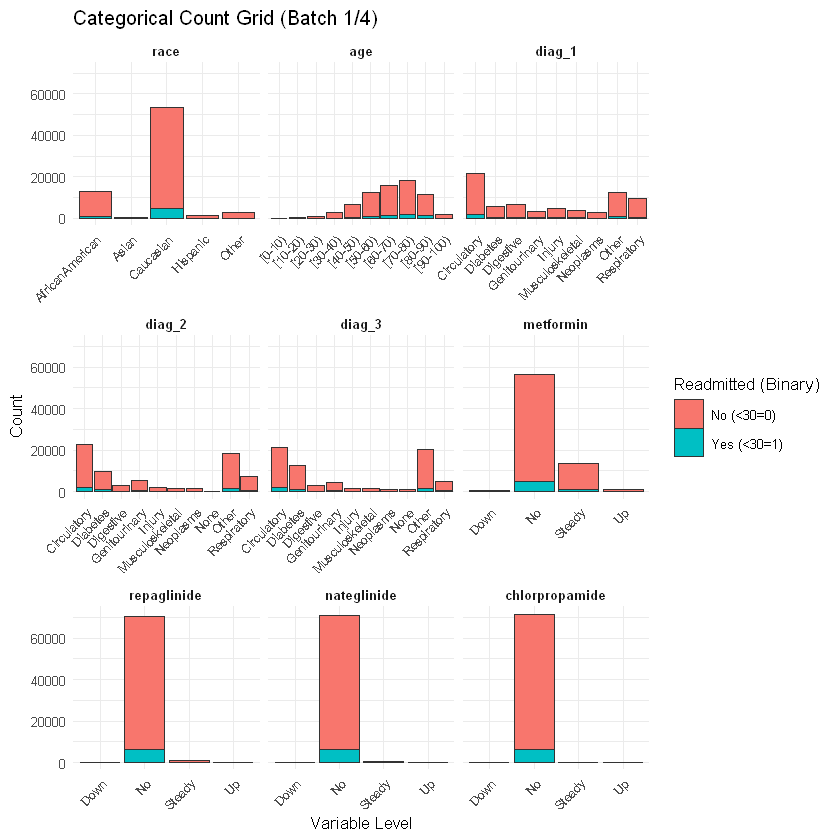

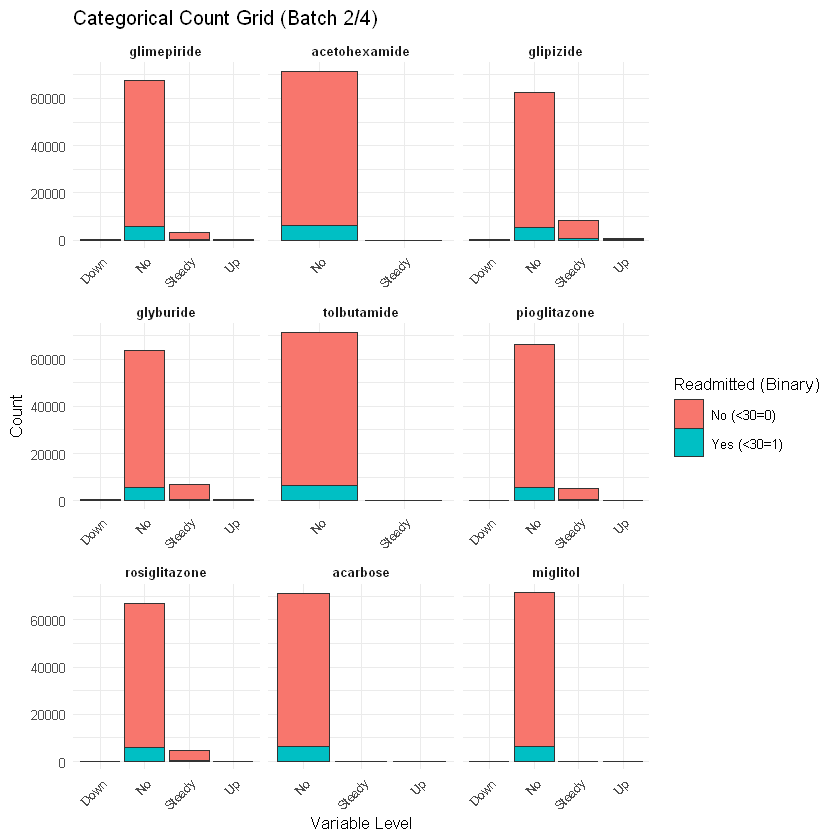

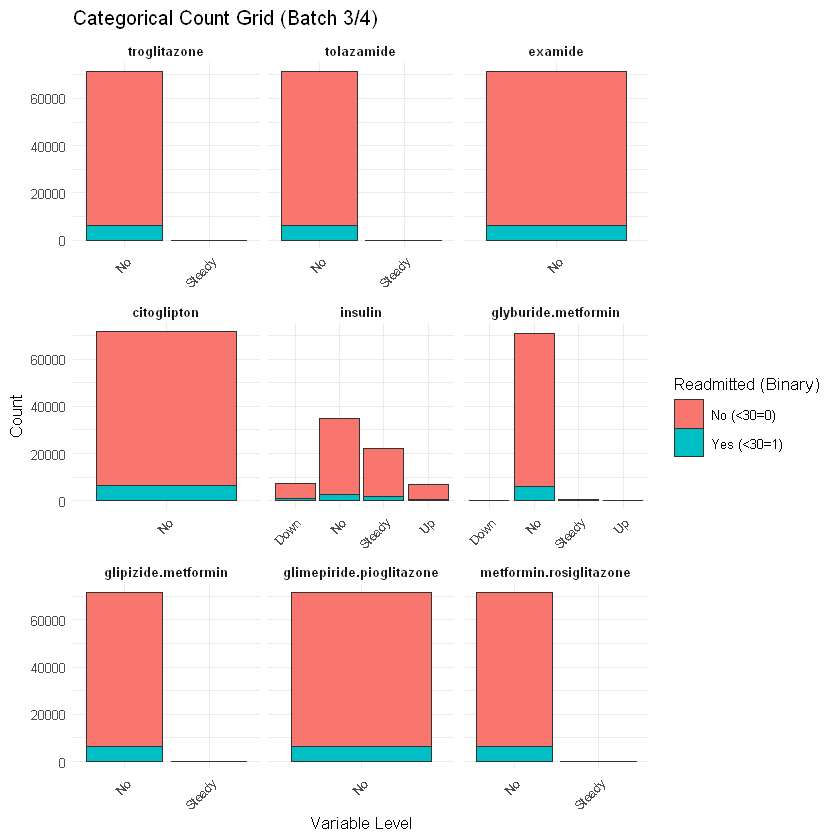

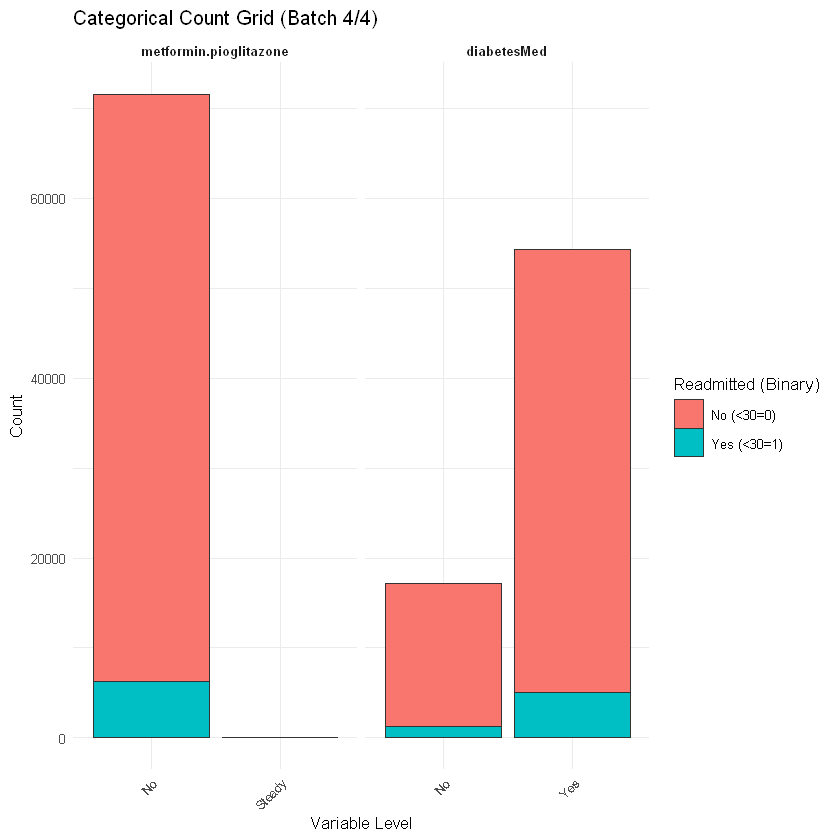

In [14]:
# Regular count bar charts for categorical variables (batched), colored by readmission class
medication_cols_plot <- intersect(
  c(
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide.metformin",
    "glipizide.metformin", "glimepiride.pioglitazone", "metformin.rosiglitazone",
    "metformin.pioglitazone", "diabetesMed"
  ),
  names(analysis_df)
)

categorical_vars_plot <- intersect(
  c("race", "age", "diag_1", "diag_2", "diag_3", medication_cols_plot),
  names(analysis_df)
)

plot_df <- analysis_df
readmit_chr <- trimws(as.character(plot_df$readmitted_binary))
readmit_num <- ifelse(
  readmit_chr %in% c("1", "Yes (<30=1)", "Yes"), 1L,
  ifelse(readmit_chr %in% c("0", "No (<30=0)", "No"), 0L, NA_integer_)
 )
plot_df$readmitted_plot <- factor(readmit_num, levels = c(0, 1), labels = c("No (<30=0)", "Yes (<30=1)"))

batch_size <- 9
var_batches <- split(categorical_vars_plot, ceiling(seq_along(categorical_vars_plot) / batch_size))

for (i in seq_along(var_batches)) {
  batch_vars <- var_batches[[i]]

  categorical_long <- plot_df %>%
    select(all_of(batch_vars), readmitted_plot) %>%
    pivot_longer(cols = -readmitted_plot, names_to = "variable", values_to = "level") %>%
    mutate(
      level = as.character(level),
      level = ifelse(is.na(level), "Missing", level),
      variable = factor(variable, levels = batch_vars)
    )

  p <- ggplot(categorical_long, aes(x = level, fill = readmitted_plot)) +
    geom_bar(position = "stack", color = "grey20", linewidth = 0.1) +
    facet_wrap(~ variable, scales = "free_x", ncol = 3) +
    labs(
      title = paste0("Categorical Count Grid (Batch ", i, "/", length(var_batches), ")"),
      x = "Variable Level",
      y = "Count",
      fill = "Readmitted (Binary)"
    ) +
    theme_minimal(base_size = 10) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
      strip.text = element_text(face = "bold")
    )

  print(p)
}

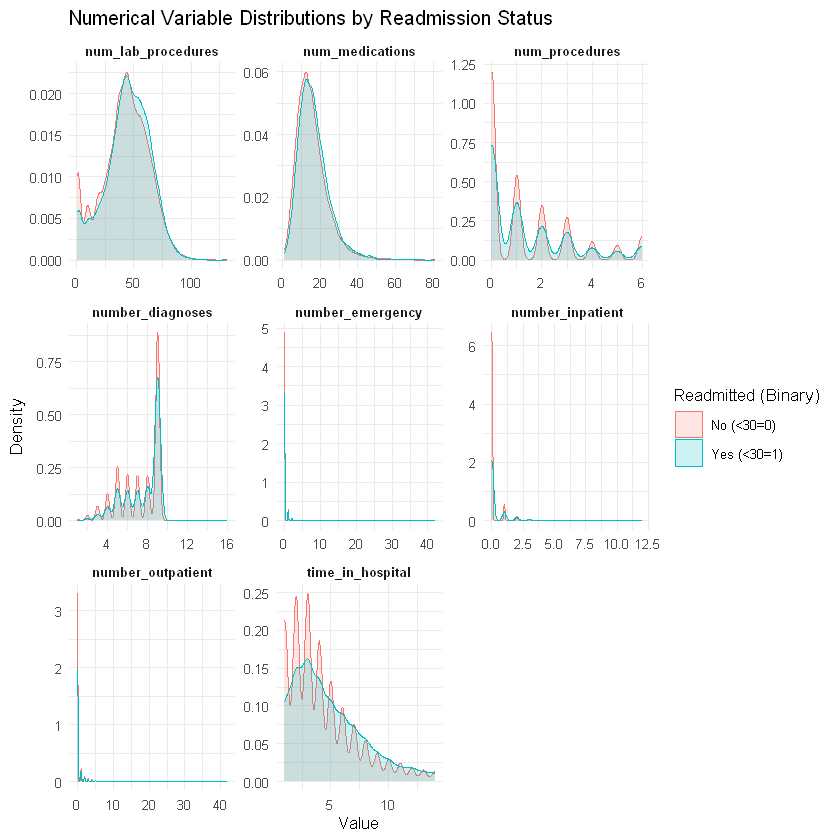

In [57]:
numeric_long <- analysis_df %>%
  select(all_of(eda_numeric_vars), readmitted_binary) %>%
  pivot_longer(cols = -readmitted_binary, names_to = "variable", values_to = "value")

ggplot(numeric_long, aes(x = value, color = readmitted_binary, fill = readmitted_binary)) +
  geom_density(alpha = 0.20, na.rm = TRUE) +
  facet_wrap(~ variable, scales = "free", ncol = 3) +
  labs(
    title = "Numerical Variable Distributions by Readmission Status",
    x = "Value",
    y = "Density",
    color = "Readmitted (Binary)",
    fill = "Readmitted (Binary)"
  ) +
  theme_minimal(base_size = 10) +
  theme(strip.text = element_text(face = "bold"))

ggsave("outputs/eda_numeric_distributions.png", width = 12, height = 8, dpi = 300)

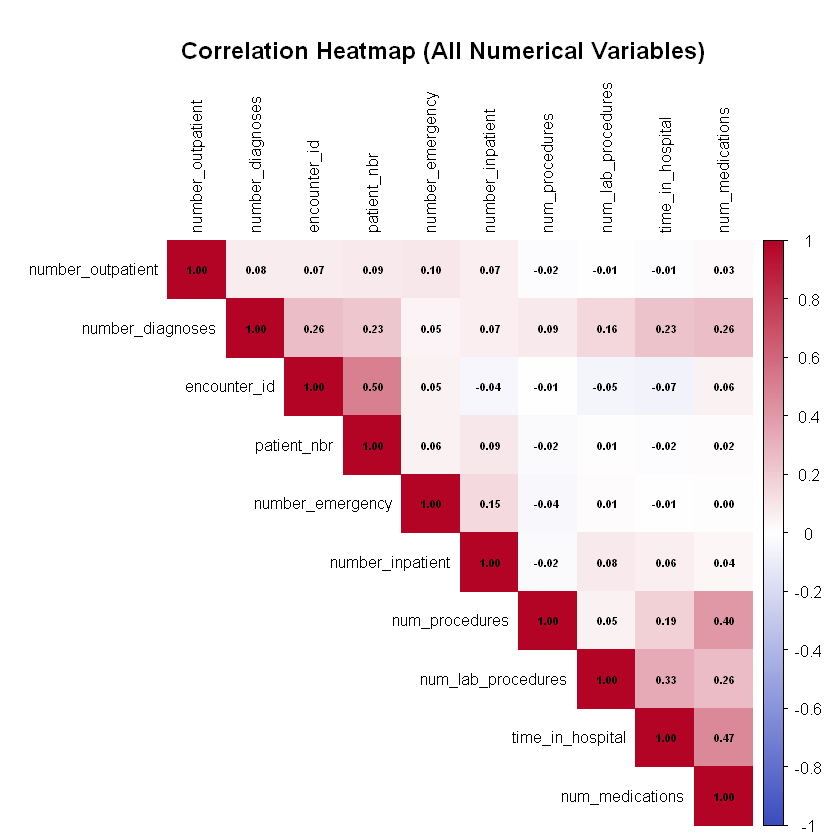

In [92]:
correlation_vars <- names(analysis_df)[sapply(analysis_df, is.numeric)]
correlation_matrix <- cor(analysis_df[correlation_vars], use = "pairwise.complete.obs")

# Dark-mode-friendly corrplot styling
op <- par(no.readonly = TRUE)
par(bg = "#ffffff", fg = "#000000")

corr_cols <- colorRampPalette(c("#3B4CC0", "#ffffff", "#B40426"))(200)

corrplot(
  correlation_matrix,
  method = "color",
  type = "upper",
  order = "hclust",
  col = corr_cols,
  addCoef.col = "#000000",
  number.cex = 0.55,
  tl.cex = 0.8,
  tl.col = "#000000",
  cl.cex = 0.8,
  mar = c(0, 0, 3, 0)
 )
ggsave("outputs/correlation_heatmap.png", width = 8, height = 6, dpi = 300)
title("Correlation Heatmap (All Numerical Variables)", col.main = "#000000")
par(op)


## Linear Models
Train and compare linear baseline models for readmission prediction.

### Data Split
Create a stratified train/test split and cross-validation folds for consistent evaluation.


In [12]:
# Prepare modeling dataset and create one shared stratified split
analysis_model_df <- analysis_df %>%
  mutate(across(where(is.character), as.factor)) %>%
  mutate(across(where(is.factor), ~fct_lump_prop(., prop = 0.01))) %>%
  select(-any_of(c("encounter_id", "patient_nbr")))

data_split <- initial_split(analysis_model_df, prop = 0.80, strata = readmitted_binary)
train_data <- training(data_split)

cv_folds <- vfold_cv(train_data, v = 5, strata = readmitted_binary)

diabetes_recipe <- recipe(readmitted_binary ~ ., data = train_data) %>%
  step_novel(all_nominal_predictors()) %>%
  step_dummy(all_nominal_predictors(), one_hot = TRUE) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())


### Logistic Regression
Tune regularized logistic regression and inspect performance across penalty settings.


In [18]:
# Tune regularized logistic regression
lr_spec <- logistic_reg(penalty = tune(), mixture = tune()) %>%
  set_engine("glmnet")

lr_workflow <- workflow() %>%
  add_recipe(diabetes_recipe) %>%
  add_model(lr_spec)

lr_grid <- grid_regular(penalty(),
                        mixture(range = c(0, 1)),
                        levels = c(penalty = 10, mixture = 2))

lr_res <- tune_grid(
  lr_workflow,
  resamples = cv_folds,
  grid = lr_grid,
  control = control_grid(save_pred = TRUE),
  metrics = metric_set(roc_auc, accuracy)
)


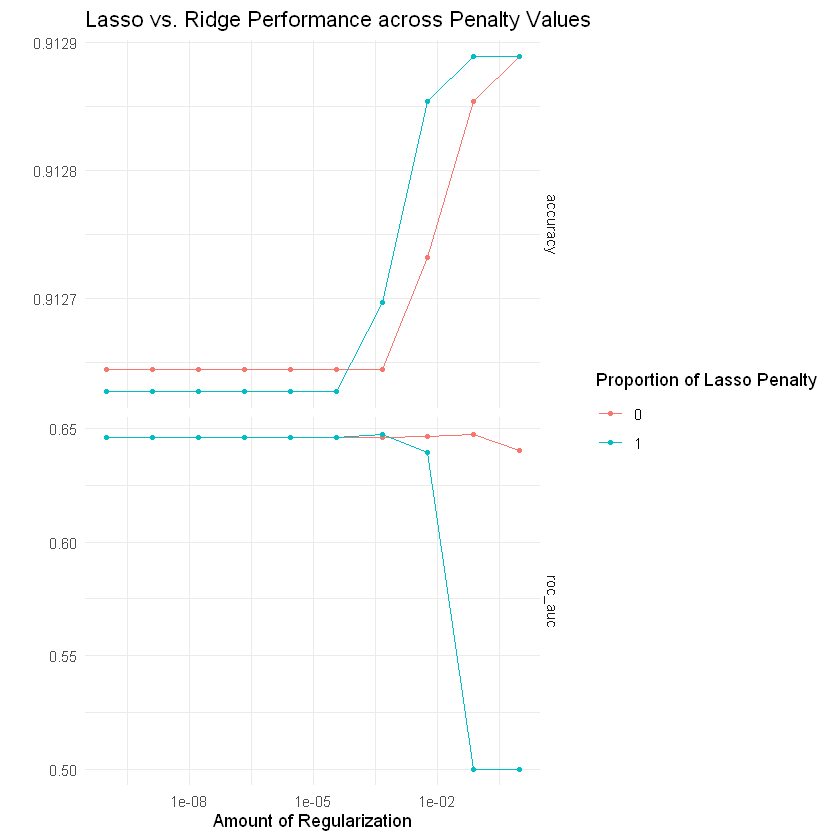

In [21]:
autoplot(lr_res) + 
  theme_minimal() + 
  labs(title = "Lasso vs. Ridge Performance across Penalty Values")

ggsave("outputs/logistic_lambda_search.png", width = 6, height = 4, dpi = 300)

In [22]:
# Select the best logistic model based on AUC
best_lr_params <- lr_res %>% select_best(metric = "roc_auc")

final_lr_workflow <- lr_workflow %>%
  finalize_workflow(best_lr_params)

final_lr_fit <- final_lr_workflow %>% fit(data = train_data)

cat("--- Best Model Parameters (Optimized for AUC) ---\n")
print(best_lr_params)
cat("\n")

lr_coefs <- final_lr_fit %>%
  extract_fit_parsnip() %>%
  tidy() %>%
  filter(term != "(Intercept)") %>%
  mutate(estimate = round(estimate, 5))

meaningful_params <- lr_coefs %>%
  filter(estimate != 0) %>%
  arrange(desc(abs(estimate)))

zeroed_params <- lr_coefs %>%
  filter(estimate == 0)

cat("--- Meaningful Predictors---\n")
print(meaningful_params, n = 30)

cat("\n--- Non-Meaningful Predictors ---\n")
cat("Total variables dropped:", nrow(zeroed_params), "\n")
head(zeroed_params$term, 20)


--- Best Model Parameters (Optimized for AUC) ---
# A tibble: 1 × 3
  penalty mixture .config         
    <dbl>   <dbl> <chr>           
1  0.0774       0 pre0_mod17_post0



Warning message:
"package 'glmnet' was built under R version 4.4.3"
Loaded glmnet 4.1-10



--- Meaningful Predictors---
# A tibble: 136 × 3
   term                                                         estimate penalty
   <chr>                                                           <dbl>   <dbl>
 1 number_inpatient                                               0.136   0.0774
 2 discharge_disposition_id_Discharged.transferred.to.another.…   0.120   0.0774
 3 discharge_disposition_id_Discharged.to.home                   -0.0889  0.0774
 4 discharge_disposition_id_Expired                              -0.0825  0.0774
 5 discharge_disposition_id_Discharged.transferred.to.SNF         0.0675  0.0774
 6 discharge_disposition_id_Discharged.transferred.to.another.…   0.0669  0.0774
 7 discharge_disposition_id_Discharged.transferred.to.another.…   0.0463  0.0774
 8 time_in_hospital                                               0.0425  0.0774
 9 number_diagnoses                                               0.0365  0.0774
10 diag_1_Respiratory                                       

character(0)

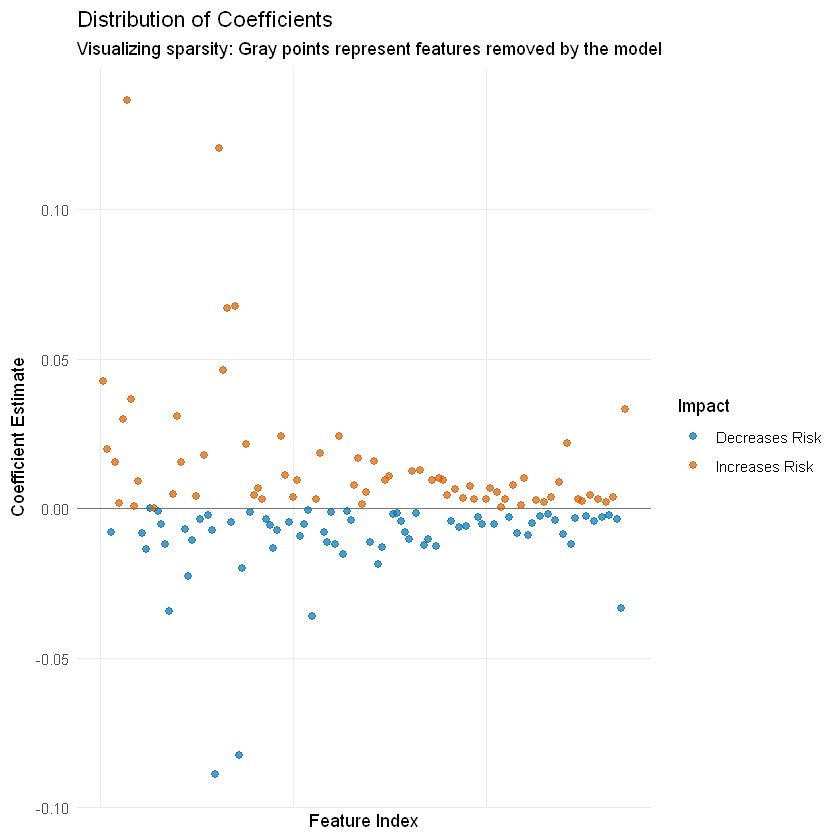

In [50]:
# Plot coefficient direction and shrinkage
general_plot_data <- lr_coefs %>%
  mutate(
    var_index = row_number(),
    Impact = case_when(
      estimate > 0 ~ "Increases Risk",
      estimate < 0 ~ "Decreases Risk",
      TRUE ~ "Zeroed Out (Noise)"
    )
  )

ggplot(general_plot_data, aes(x = var_index, y = estimate, color = Impact)) +
  geom_hline(yintercept = 0, linetype = "solid", color = "black", alpha = 0.5) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_manual(values = c(
    "Increases Risk" = "#D55E00",
    "Decreases Risk" = "#0072B2",
    "Zeroed Out (Noise)" = "gray80"
  )) +
  labs(
    title = "Distribution of Coefficients",
    subtitle = "Visualizing sparsity: Gray points represent features removed by the model",
    x = "Feature Index",
    y = "Coefficient Estimate"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_blank(),
    panel.grid.minor = element_blank()
  )
ggsave("outputs/lr_coefficients_plot.png", width = 8, height = 5, dpi = 300)


--- Final Logistic Regression Performance (Test Set) ---\n# A tibble: 4 × 3
  .metric   .estimator .estimate
  <chr>     <chr>          <dbl>
1 roc_auc   binary         0.648
2 precision binary         0.909
3 recall    binary         1.00 
4 f_meas    binary         0.952
\n--- Confusion Matrix Performance (Logistic Regression) ---\n# A tibble: 13 × 3
   .metric              .estimator .estimate
   <chr>                <chr>          <dbl>
 1 accuracy             binary      0.909   
 2 kap                  binary      0.00125 
 3 sens                 binary      1.00    
 4 spec                 binary      0.000765
 5 ppv                  binary      0.909   
 6 npv                  binary      0.500   
 7 mcc                  binary      0.0168  
 8 j_index              binary      0.000688
 9 bal_accuracy         binary      0.500   
10 detection_prevalence binary      1.00    
11 precision            binary      0.909   
12 recall               binary      1.00    
13 f_meas      

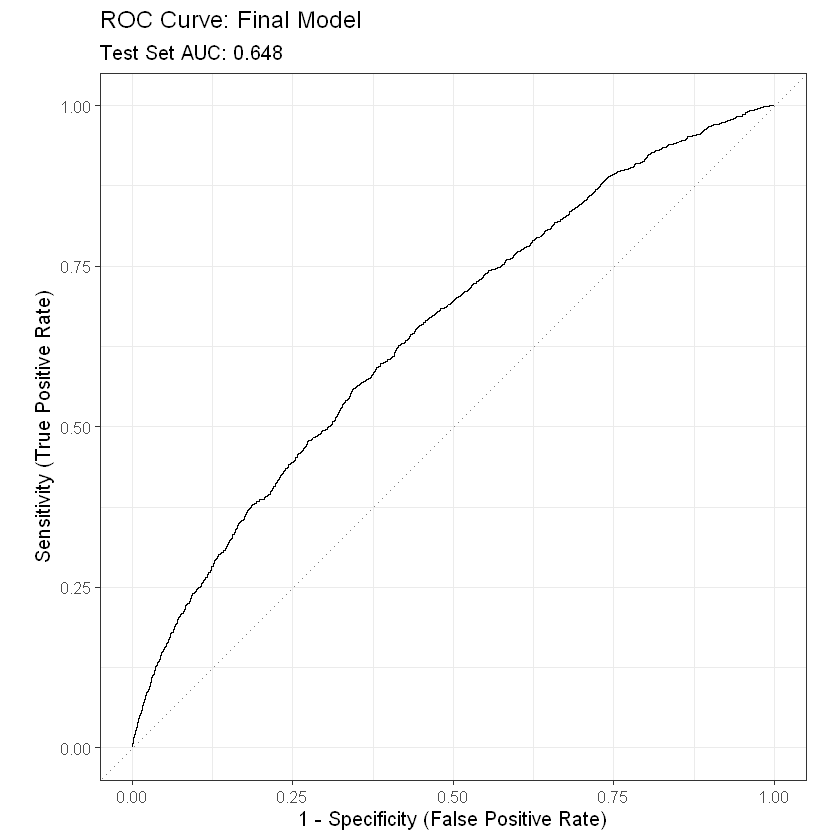

In [77]:
# Evaluate final logistic model on the test split
final_res <- last_fit(final_lr_workflow, data_split)

lr_preds <- final_res %>%
  collect_predictions()

white_theme <- theme_bw(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    legend.background = element_rect(fill = "white", color = NA),
    legend.key = element_rect(fill = "white", color = NA)
  )

pred_prob_cols <- names(lr_preds)[
  grepl("^\\.pred_", names(lr_preds)) & names(lr_preds) != ".pred_class"
 ]

if (length(pred_prob_cols) == 0) {
  stop("No probability prediction columns found in lr_preds.")
}

lr_prob_col <- pred_prob_cols[grepl("Yes", pred_prob_cols, fixed = TRUE)]
if (length(lr_prob_col) == 0) {
  lr_prob_col <- pred_prob_cols[1]
}
lr_prob_col <- lr_prob_col[[1]]

lr_metrics <- dplyr::bind_rows(
  roc_auc(lr_preds, truth = readmitted_binary, !!rlang::sym(lr_prob_col), event_level = "second"),
  precision(lr_preds, truth = readmitted_binary, estimate = .pred_class),
  recall(lr_preds, truth = readmitted_binary, estimate = .pred_class),
  f_meas(lr_preds, truth = readmitted_binary, estimate = .pred_class)
)

lr_cm <- conf_mat(lr_preds, truth = readmitted_binary, estimate = .pred_class)
lr_cm_perf <- summary(lr_cm)

cat("--- Final Logistic Regression Performance (Test Set) ---\\n")
print(lr_metrics)
cat("\\n--- Confusion Matrix Performance (Logistic Regression) ---\\n")
print(lr_cm_perf)
cat("\\n--- Confusion Matrix (Logistic Regression) ---\\n")
print(lr_cm)

lr_preds %>%
  roc_curve(truth = readmitted_binary, !!rlang::sym(lr_prob_col), event_level = "second") %>%
  autoplot() +
  geom_abline(lty = 3, color = "gray50") +
  labs(
    title = "ROC Curve: Final Model",
    subtitle = paste0("Test Set AUC: ", round(dplyr::filter(lr_metrics, .metric == "roc_auc")$.estimate, 3)),
    x = "1 - Specificity (False Positive Rate)",
    y = "Sensitivity (True Positive Rate)"
  ) +
  white_theme

ggsave("outputs/lr_final_roc_curve.png", width = 6, height = 4, dpi = 300, bg = "white")


### GAM
Fit a generalized additive model to capture smooth nonlinear effects in key predictors.


In [78]:
# Build and evaluate GAM on the shared train/test split

gam_simple_form <- readmitted_binary ~ time_in_hospital + num_lab_procedures + 
  num_medications + number_diagnoses + number_inpatient + 
  number_emergency + race + gender + age + diabetesMed + insulin + 
  discharge_disposition_id

gam_spline_form <- as.formula(
  readmitted_binary ~ s(time_in_hospital, k = 5) + s(num_lab_procedures, k = 5) +
  s(num_medications, k = 5) + s(number_diagnoses, k = 5) + s(number_inpatient, k = 5) +
  s(number_emergency, k = 5) + race + gender + age + diabetesMed + insulin +
  discharge_disposition_id
)

gam_spec <- gen_additive_mod() %>%
  set_engine("mgcv") %>%
  set_mode("classification")

gam_workflow <- workflow() %>%
  add_formula(gam_simple_form) %>%
  add_model(gam_spec, formula = gam_spline_form)

gam_fit <- gam_workflow %>% fit(data = train_data)
gam_test_res <- last_fit(gam_workflow, split = data_split)

gam_fit


══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Formula
Model: gen_additive_mod()

── Preprocessor ────────────────────────────────────────────────────────────────
readmitted_binary ~ time_in_hospital + num_lab_procedures + num_medications + 
    number_diagnoses + number_inpatient + number_emergency + 
    race + gender + age + diabetesMed + insulin + discharge_disposition_id

── Model ───────────────────────────────────────────────────────────────────────

Family: binomial 
Link function: logit 

Formula:
readmitted_binary ~ s(time_in_hospital, k = 5) + s(num_lab_procedures, 
    k = 5) + s(num_medications, k = 5) + s(number_diagnoses, 
    k = 5) + s(number_inpatient, k = 5) + s(number_emergency, 
    k = 5) + race + gender + age + diabetesMed + insulin + discharge_disposition_id

Estimated degrees of freedom:
3.30 2.18 1.04 2.39 2.65 2.10  total = 39.65 

UBRE score: -0.4338011     

--- Final GAM Performance (Test Set) ---\n# A tibble: 4 × 3
  .metric   .estimator .estimate
  <chr>     <chr>          <dbl>
1 roc_auc   binary         0.648
2 precision binary         0.909
3 recall    binary         1.00 
4 f_meas    binary         0.952
\n--- Confusion Matrix Performance (GAM) ---\n# A tibble: 13 × 3
   .metric              .estimator .estimate
   <chr>                <chr>          <dbl>
 1 accuracy             binary       0.909  
 2 kap                  binary       0.00373
 3 sens                 binary       1.00   
 4 spec                 binary       0.00229
 5 ppv                  binary       0.909  
 6 npv                  binary       0.500  
 7 mcc                  binary       0.0290 
 8 j_index              binary       0.00206
 9 bal_accuracy         binary       0.501  
10 detection_prevalence binary       1.00   
11 precision            binary       0.909  
12 recall               binary       1.00   
13 f_meas               binary       0.952  
\n

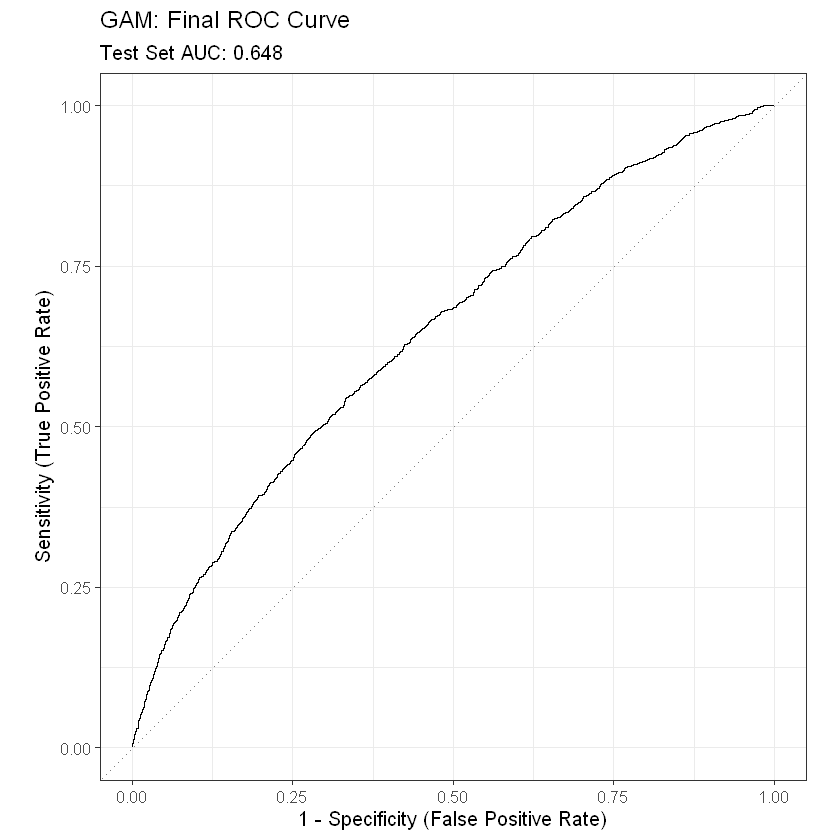

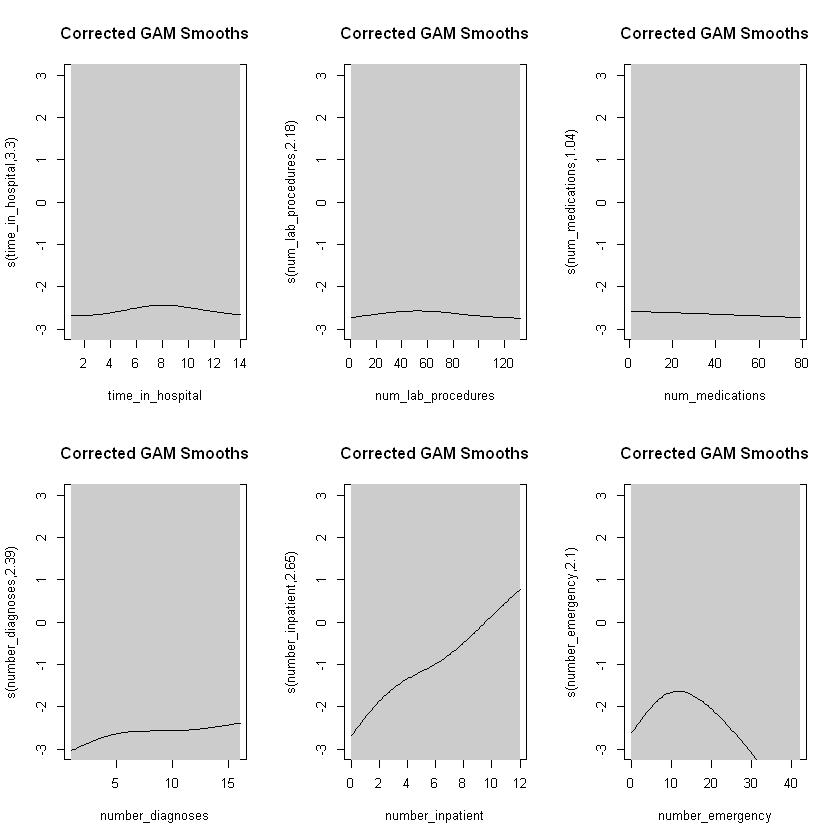

In [80]:
gam_preds <- collect_predictions(gam_test_res)

white_theme <- theme_bw(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    legend.background = element_rect(fill = "white", color = NA),
    legend.key = element_rect(fill = "white", color = NA)
  )

pred_prob_cols <- names(gam_preds)[
  grepl("^\\.pred_", names(gam_preds)) & names(gam_preds) != ".pred_class"
 ]

if (length(pred_prob_cols) == 0) {
  stop("No probability prediction columns found in gam_preds.")
}

gam_prob_col <- pred_prob_cols[grepl("Yes", pred_prob_cols, fixed = TRUE)]
if (length(gam_prob_col) == 0) {
  gam_prob_col <- pred_prob_cols[1]
}
gam_prob_col <- gam_prob_col[[1]]

gam_metrics <- dplyr::bind_rows(
  roc_auc(gam_preds, truth = readmitted_binary, !!rlang::sym(gam_prob_col), event_level = "second"),
  precision(gam_preds, truth = readmitted_binary, estimate = .pred_class),
  recall(gam_preds, truth = readmitted_binary, estimate = .pred_class),
  f_meas(gam_preds, truth = readmitted_binary, estimate = .pred_class)
)

gam_cm <- conf_mat(gam_preds, truth = readmitted_binary, estimate = .pred_class)
gam_cm_perf <- summary(gam_cm)

cat("--- Final GAM Performance (Test Set) ---\\n")
print(gam_metrics)
cat("\\n--- Confusion Matrix Performance (GAM) ---\\n")
print(gam_cm_perf)
cat("\\n--- Confusion Matrix (GAM) ---\\n")
print(gam_cm)

p_gam_roc <- gam_preds %>%
  roc_curve(truth = readmitted_binary, !!rlang::sym(gam_prob_col), event_level = "second") %>%
  autoplot() +
  geom_abline(lty = 3, color = "gray50") +
  labs(
    title = "GAM: Final ROC Curve",
    subtitle = paste0("Test Set AUC: ", round(dplyr::filter(gam_metrics, .metric == "roc_auc")$.estimate, 3)),
    x = "1 - Specificity (False Positive Rate)",
    y = "Sensitivity (True Positive Rate)"
  ) +
  white_theme

print(p_gam_roc)
ggsave("outputs/gam_final_roc_curve.png", plot = p_gam_roc, width = 6, height = 4, dpi = 300, bg = "white")

gam_engine <- extract_fit_engine(gam_fit)

par(mfrow = c(2, 3), bg = "white")
plot(
  gam_engine,
  pages = 1,
  shade = TRUE,
  seWithMean = TRUE,
  ylim = c(-3, 3),
  shift = coef(gam_engine)[1],
  main = "Corrected GAM Smooths"
 )
ggsave("outputs/gam_smooth_plots.png", width = 10, height = 6, dpi = 300)


## Nonlinear Models
Evaluate tree-based models to compare against linear methods.

### Random Forest
Tune a random forest model and review variable importance and predictive performance.


In [13]:
# Random forest specification (second pass: imbalance-aware tuning)
class_levels <- levels(train_data$readmitted_binary)
if (length(class_levels) != 2) {
  stop("readmitted_binary must be a 2-level factor for class weighting.")
}

neg_label <- class_levels[1]
pos_label <- class_levels[2]
neg_n <- sum(train_data$readmitted_binary == neg_label, na.rm = TRUE)
pos_n <- sum(train_data$readmitted_binary == pos_label, na.rm = TRUE)

rf_pos_weight <- neg_n / pos_n
rf_class_weights <- c(1, rf_pos_weight)
names(rf_class_weights) <- class_levels

cat("RF class weights:\n")
print(rf_class_weights)

rf_spec <- rand_forest(
    mtry = tune(),
    trees = 500,
    min_n = tune()
  ) %>%
  set_engine("ranger", 
              importance = "impurity",
              num.threads = parallel::detectCores(),
              class.weights = rf_class_weights) %>%
  set_mode("classification")

rf_workflow <- workflow() %>%
  add_recipe(diabetes_recipe) %>%
  add_model(rf_spec)

set.seed(PROJECT_SEED)
rf_grid <- grid_space_filling(
  finalize(mtry(), train_data),
  min_n(),
  size = 10
)

rf_res <- tune_race_anova(
  rf_workflow,
  resamples = cv_folds,
  grid = rf_grid,
  metrics = metric_set(pr_auc, roc_auc, bal_accuracy),
  control = control_race(
    save_pred = TRUE, 
    verbose_elim = TRUE,
    event_level = "second"
  )
)

RF class weights:
 No (<30=0) Yes (<30=1) 
    1.00000    10.47963 


ℹ Evaluating against the initial 3 burn-in resamples.
ℹ Racing will maximize the pr_auc metric.
ℹ Resamples are analyzed in a random order.
ℹ Fold2: 8 eliminated; 2 candidates remain.

ℹ Fold5: All but one parameter combination were eliminated.



In [14]:
best_rf <- rf_res %>% select_best(metric = "pr_auc")

rf_final_wf <- finalize_workflow(rf_workflow, best_rf)
rf_final_res <- last_fit(rf_final_wf, data_split)

rf_preds <- collect_predictions(rf_final_res)

pred_prob_cols <- names(rf_preds)[
  grepl("^\\.pred_", names(rf_preds)) & names(rf_preds) != ".pred_class"
 ]

if (length(pred_prob_cols) == 0) {
  stop("No probability prediction columns found in rf_preds.")
}

rf_prob_col <- pred_prob_cols[grepl("Yes", pred_prob_cols, fixed = TRUE)]
if (length(rf_prob_col) == 0) {
  rf_prob_col <- pred_prob_cols[1]
}
rf_prob_col <- rf_prob_col[[1]]

rf_metrics <- dplyr::bind_rows(
  pr_auc(rf_preds, truth = readmitted_binary, !!rlang::sym(rf_prob_col), event_level = "second"),
  roc_auc(rf_preds, truth = readmitted_binary, !!rlang::sym(rf_prob_col), event_level = "second"),
  bal_accuracy(rf_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second"),
  precision(rf_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second"),
  recall(rf_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second"),
  specificity(rf_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second"),
  f_meas(rf_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second")
)
rf_cm <- conf_mat(rf_preds, truth = readmitted_binary, estimate = .pred_class)
rf_cm_perf <- summary(rf_cm)

cat("--- Final Random Forest Performance (Test Set, Second Pass) --- \n")
print(rf_metrics)
cat("\\n--- Confusion Matrix Performance (Random Forest) ---\\n")
print(rf_cm_perf)
cat("\\n--- Confusion Matrix (Random Forest) ---\\n")
print(rf_cm)

Warning message:
"While computing binary `precision()`, no predicted events were detected (i.e.
`true_positive + false_positive = 0`).
Precision is undefined in this case, and `NA` will be returned.
Note that 1308 true event(s) actually occurred for the problematic event level,
Yes (<30=1)"
Warning message:
"While computing binary `precision()`, no predicted events were detected (i.e.
`true_positive + false_positive = 0`).
Precision is undefined in this case, and `NA` will be returned.
Note that 1308 true event(s) actually occurred for the problematic event level,
Yes (<30=1)"


--- Final Random Forest Performance (Test Set, Second Pass) --- 
# A tibble: 7 × 3
  .metric      .estimator .estimate
  <chr>        <chr>          <dbl>
1 pr_auc       binary         0.179
2 roc_auc      binary         0.650
3 bal_accuracy binary         0.5  
4 precision    binary        NA    
5 recall       binary         0    
6 specificity  binary         1    
7 f_meas       binary        NA    
\n--- Confusion Matrix Performance (Random Forest) ---\n# A tibble: 13 × 3
   .metric              .estimator .estimate
   <chr>                <chr>          <dbl>
 1 accuracy             binary         0.909
 2 kap                  binary         0    
 3 sens                 binary         1    
 4 spec                 binary         0    
 5 ppv                  binary         0.909
 6 npv                  binary       NaN    
 7 mcc                  binary        NA    
 8 j_index              binary         0    
 9 bal_accuracy         binary         0.5  
10 detection_prevalence

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


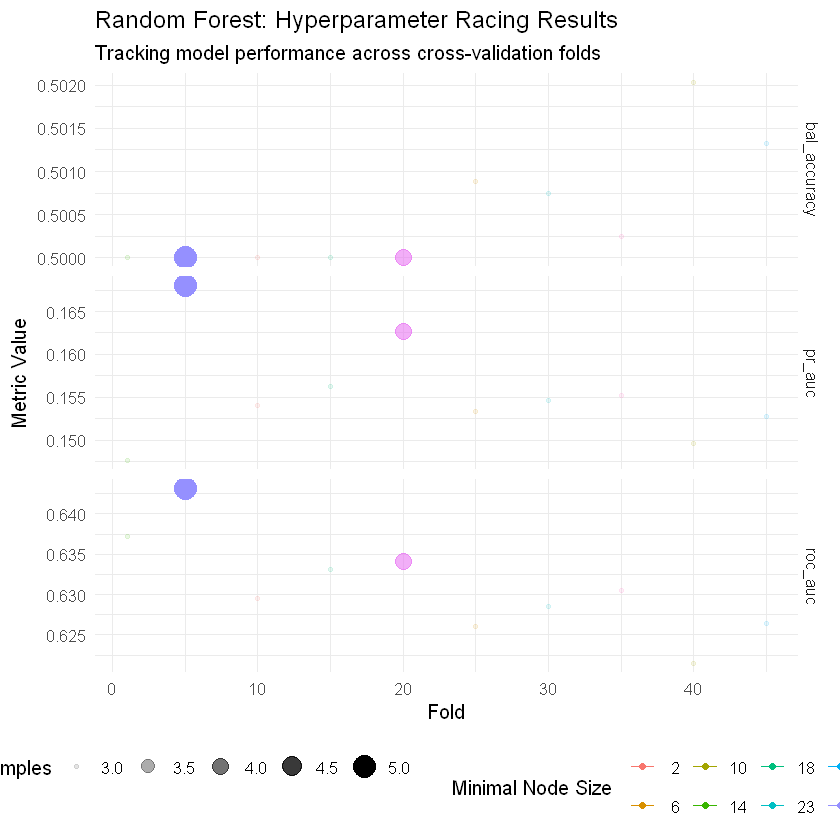

In [15]:
# Racing Plot
p_racing <- autoplot(rf_res) + 
  theme_minimal(base_size = 12) + 
  labs(
    title = "Random Forest: Hyperparameter Racing Results",
    subtitle = "Tracking model performance across cross-validation folds",
    x = "Fold",
    y = "Metric Value"
  ) +
  theme(legend.position = "bottom")

print(p_racing)
ggsave(p_racing, filename = "outputs/rf_racing_plot.png", width = 7, height = 5, dpi = 300)

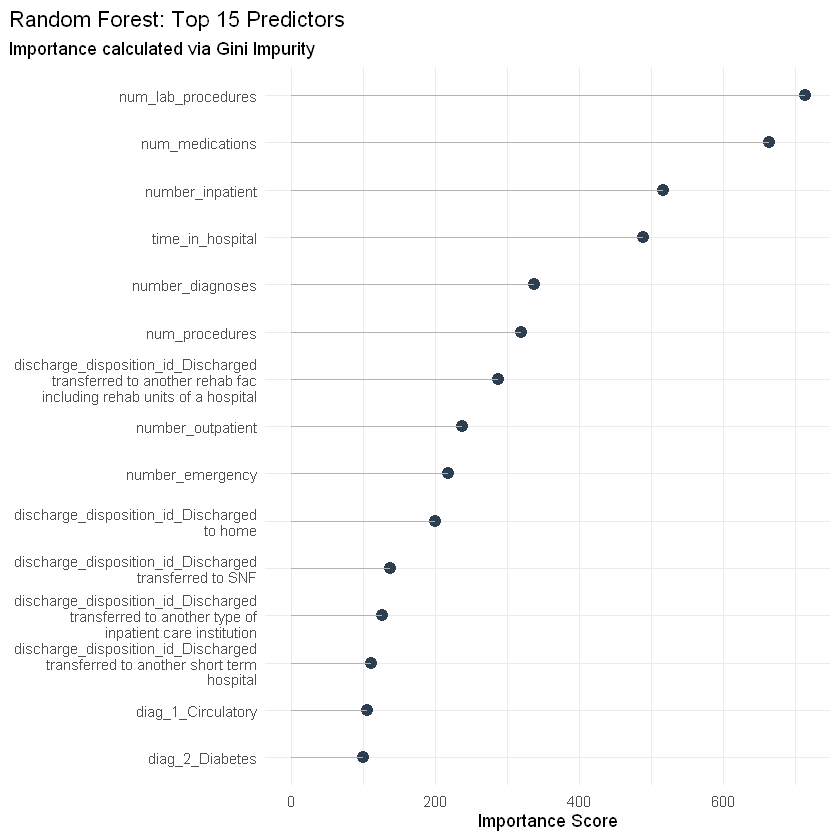

In [16]:
# Predictor Importance Plot
p_vip <- rf_final_res %>%
  extract_fit_parsnip() %>%
  vi(method = "model") %>% 
  mutate(
    Variable = str_replace_all(Variable, "\\.", " "),
    Variable = str_wrap(Variable, width = 35), 
    Variable = fct_reorder(Variable, Importance)
  ) %>%
  slice_max(Importance, n = 15) %>%
  ggplot(aes(x = Importance, y = Variable)) +
  geom_point(color = "#2c3e50", size = 3) +
  geom_segment(aes(x = 0, xend = Importance, y = Variable, yend = Variable), color = "grey70") +
  theme_minimal(base_size = 11) +
  labs(
    title = "Random Forest: Top 15 Predictors",
    subtitle = "Importance calculated via Gini Impurity",
    x = "Importance Score",
    y = NULL
  ) +
  theme(
    plot.title.position = "plot",
    axis.text.y = element_text(lineheight = 0.9)
  )

print(p_vip)
ggsave(p_vip, filename = "outputs/rf_variable_importance.png", width = 6, height = 4, dpi = 300)

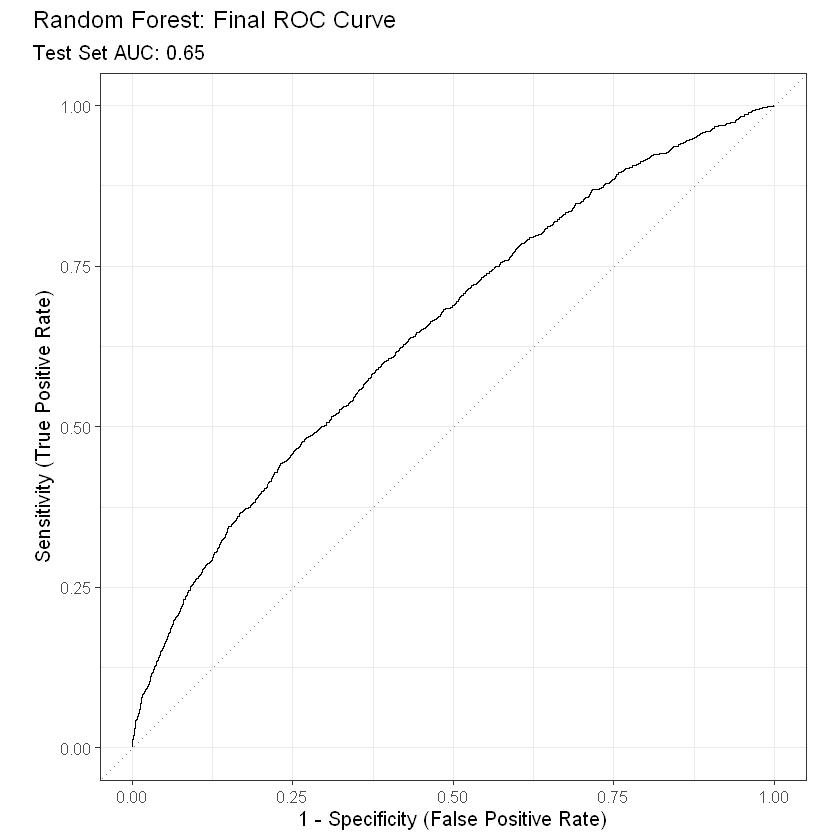

In [17]:
# ROC Curve Plot
white_theme <- theme_bw(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    legend.background = element_rect(fill = "white", color = NA),
    legend.key = element_rect(fill = "white", color = NA),
    plot.title.position = "plot"
  )

# REVERT: Added event_level = "second" to flip the curve
p_rf_roc <- rf_preds %>%
  roc_curve(truth = readmitted_binary, !!rlang::sym(rf_prob_col), event_level = "second") %>%
  autoplot() +
  geom_abline(lty = 3, color = "gray50") + # Adds the 0.5 baseline for reference
  white_theme +
  labs(
    title = "Random Forest: Final ROC Curve",
    subtitle = paste0("Test Set AUC: ", round(rf_metrics$.estimate[rf_metrics$.metric == "roc_auc"], 3)),
    x = "1 - Specificity (False Positive Rate)",
    y = "Sensitivity (True Positive Rate)"
  )

# Display and Save
print(p_rf_roc)

if(!dir.exists("outputs")) dir.create("outputs")
ggsave(plot = p_rf_roc, filename = "outputs/rf_final_roc_curve.png", width = 6, height = 4, dpi = 300, bg = "white")


### XGBoost
Tune gradient-boosted trees and compare final metrics with other candidate models.


In [20]:
# XGBoost specification with tuning parameters (second pass: imbalance-aware)
class_levels <- levels(train_data$readmitted_binary)
if (length(class_levels) != 2) {
  stop("readmitted_binary must be a 2-level factor for class weighting.")
}

neg_label <- class_levels[1]
pos_label <- class_levels[2]
neg_n <- sum(train_data$readmitted_binary == neg_label, na.rm = TRUE)
pos_n <- sum(train_data$readmitted_binary == pos_label, na.rm = TRUE)

xgb_scale_pos_weight <- neg_n / pos_n
cat("XGBoost scale_pos_weight:", round(xgb_scale_pos_weight, 3), "\n")

xgb_spec_opt <- boost_tree(
  trees = 1000, 
  tree_depth = tune(),
  min_n = tune(),
  loss_reduction = tune(),
  learn_rate = tune(),
  sample_size = tune()
) %>%
  set_engine("xgboost", 
             nthread = parallel::detectCores(),
             early_stopping_rounds = 10,
             eval_metric = "auc",
             scale_pos_weight = xgb_scale_pos_weight) %>% 
  set_mode("classification")

xgb_workflow_opt <- workflow() %>%
  add_recipe(diabetes_recipe) %>%
  add_model(xgb_spec_opt)

xgb_grid_opt <- grid_space_filling(
  tree_depth(range = c(3, 10)),
  min_n(),
  loss_reduction(),
  learn_rate(range = c(-3, -1), trans = log10_trans()), 
  sample_size = sample_prop(),
  size = 20 
)

xgb_res <- tune_race_anova(
  xgb_workflow_opt,
  resamples = cv_folds,
  grid = xgb_grid_opt,
  metrics = metric_set(roc_auc, pr_auc, bal_accuracy),
  control = control_race(
    save_pred = TRUE, 
    verbose_elim = TRUE,
    event_level = "second",
    parallel_over = "everything" 
  )
)

XGBoost scale_pos_weight: 10.48 


ℹ Evaluating against the initial 3 burn-in resamples.
ℹ Racing will maximize the roc_auc metric.
ℹ Resamples are analyzed in a random order.
ℹ Fold5: 17 eliminated; 3 candidates remain.

ℹ Fold3: 1 eliminated; 2 candidates remain.



Warning message:
"While computing binary `precision()`, no predicted events were detected (i.e.
`true_positive + false_positive = 0`).
Precision is undefined in this case, and `NA` will be returned.
Note that 1308 true event(s) actually occurred for the problematic event level,
Yes (<30=1)"
Warning message:
"While computing binary `precision()`, no predicted events were detected (i.e.
`true_positive + false_positive = 0`).
Precision is undefined in this case, and `NA` will be returned.
Note that 1308 true event(s) actually occurred for the problematic event level,
Yes (<30=1)"


--- Final XGBoost Performance (Test Set, Second Pass) ---
# A tibble: 7 × 3
  .metric      .estimator .estimate
  <chr>        <chr>          <dbl>
1 roc_auc      binary         0.651
2 pr_auc       binary         0.181
3 bal_accuracy binary         0.5  
4 precision    binary        NA    
5 recall       binary         0    
6 specificity  binary         1    
7 f_meas       binary        NA    

--- Confusion Matrix Performance (XGBoost) ---
# A tibble: 13 × 3
   .metric              .estimator .estimate
   <chr>                <chr>          <dbl>
 1 accuracy             binary         0.909
 2 kap                  binary         0    
 3 sens                 binary         1    
 4 spec                 binary         0    
 5 ppv                  binary         0.909
 6 npv                  binary       NaN    
 7 mcc                  binary        NA    
 8 j_index              binary         0    
 9 bal_accuracy         binary         0.5  
10 detection_prevalence binary        

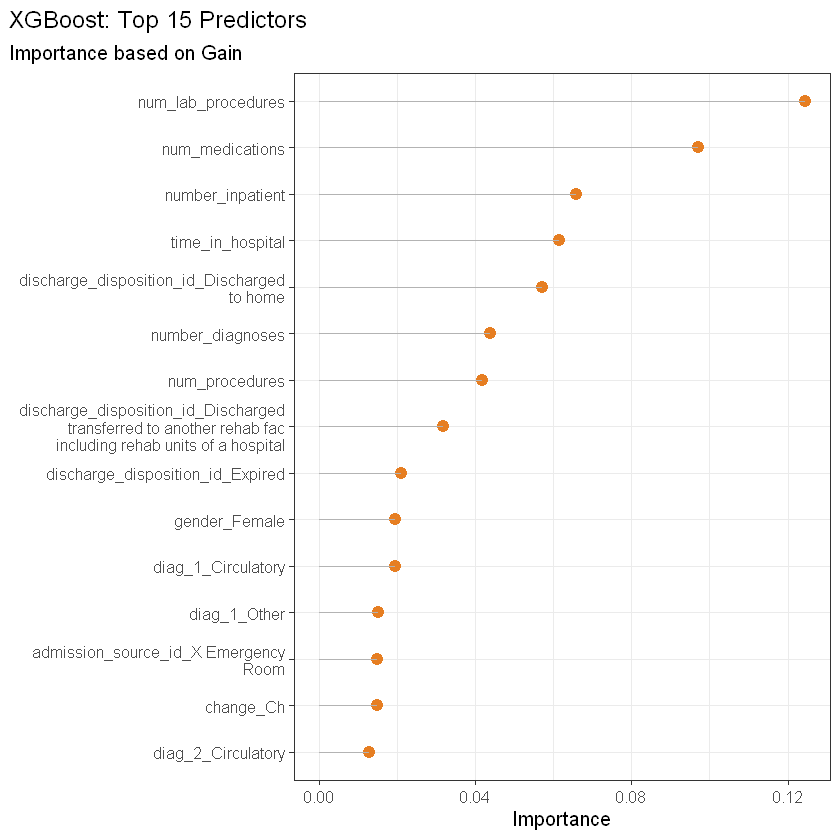

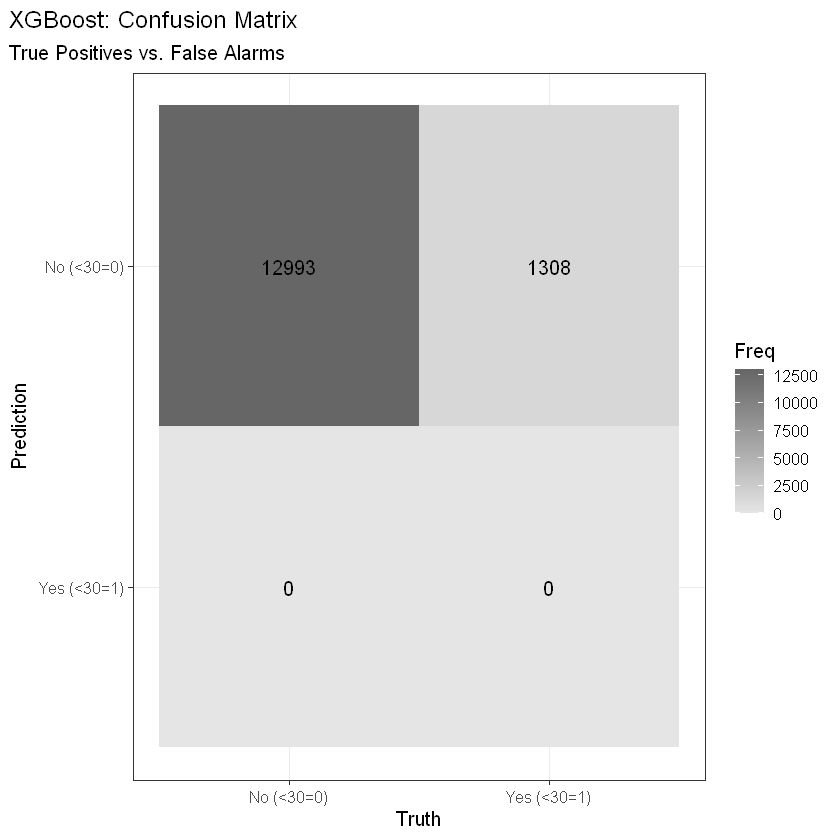

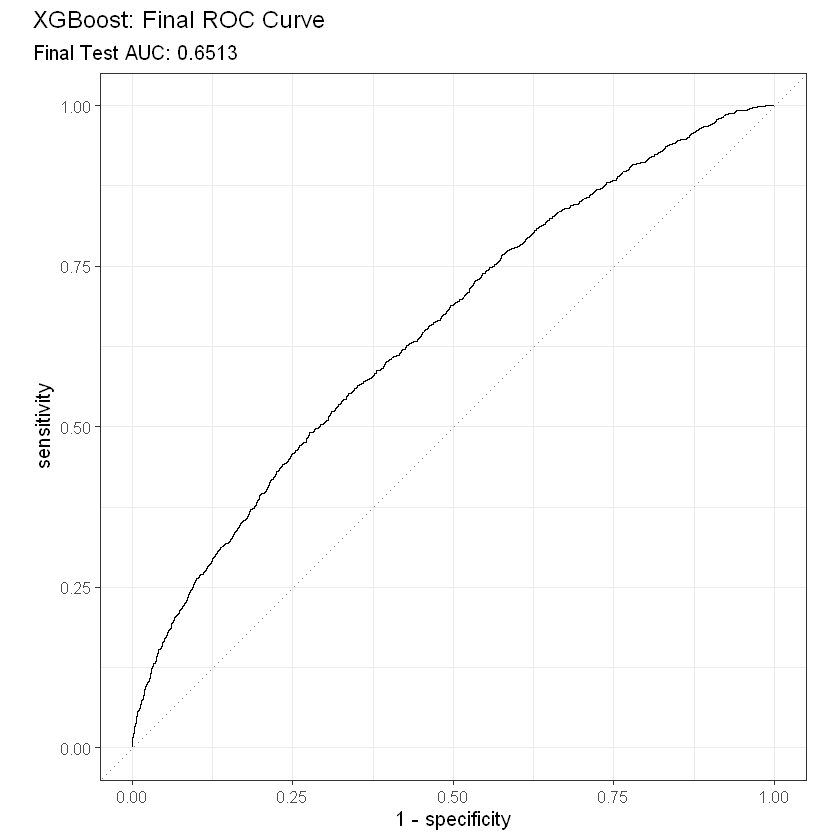

In [21]:
white_theme <- theme_bw(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    legend.background = element_rect(fill = "white", color = NA),
    legend.key = element_rect(fill = "white", color = NA),
    plot.title.position = "plot"
  )

if (!exists("xgb_res")) {
  stop("xgb_res not found. Please rerun the XGBoost tuning cell first.")
}

best_xgb <- select_best(xgb_res, metric = "roc_auc")
xgb_final_wf <- finalize_workflow(xgb_workflow_opt, best_xgb)
xgb_final_fit <- last_fit(xgb_final_wf, data_split)

xgb_preds <- collect_predictions(xgb_final_fit)

pred_prob_cols <- names(xgb_preds)[
  grepl("^\\.pred_", names(xgb_preds)) & names(xgb_preds) != ".pred_class"
]

xgb_prob_col <- pred_prob_cols[grepl("Yes", pred_prob_cols, fixed = TRUE)]
if (length(xgb_prob_col) == 0) {
  xgb_prob_col <- pred_prob_cols[1]
}
xgb_prob_col <- xgb_prob_col[[1]]

xgb_metrics <- dplyr::bind_rows(
  roc_auc(xgb_preds, truth = readmitted_binary, !!rlang::sym(xgb_prob_col), event_level = "second"),
  pr_auc(xgb_preds, truth = readmitted_binary, !!rlang::sym(xgb_prob_col), event_level = "second"),
  bal_accuracy(xgb_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second"),
  precision(xgb_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second"),
  recall(xgb_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second"),
  specificity(xgb_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second"),
  f_meas(xgb_preds, truth = readmitted_binary, estimate = .pred_class, event_level = "second")
)

xgb_cm <- conf_mat(xgb_preds, truth = readmitted_binary, estimate = .pred_class)
xgb_cm_perf <- summary(xgb_cm)

cat("--- Final XGBoost Performance (Test Set, Second Pass) ---\n")
print(xgb_metrics)
cat("\n--- Confusion Matrix Performance (XGBoost) ---\n")
print(xgb_cm_perf)

p_xgb_vip <- xgb_final_fit %>%
  extract_fit_parsnip() %>%
  vip::vi(method = "model") %>%
  mutate(
    Variable = str_replace_all(Variable, "\\.", " "),
    Variable = str_wrap(Variable, width = 35),
    Variable = fct_reorder(Variable, Importance)
  ) %>%
  slice_max(Importance, n = 15) %>%
  ggplot(aes(x = Importance, y = Variable)) +
  geom_point(color = "#e67e22", size = 3) +
  geom_segment(aes(x = 0, xend = Importance, y = Variable, yend = Variable), color = "grey70") +
  white_theme +
  labs(
    title = "XGBoost: Top 15 Predictors",
    subtitle = "Importance based on Gain",
    y = NULL
  )

p_xgb_cm <- xgb_cm %>%
  autoplot(type = "heatmap") +
  white_theme +
  labs(
    title = "XGBoost: Confusion Matrix",
    subtitle = "True Positives vs. False Alarms"
  )

p_xgb_roc <- xgb_preds %>%
  roc_curve(truth = readmitted_binary, !!rlang::sym(xgb_prob_col), event_level = "second") %>%
  autoplot() +
  geom_abline(lty = 3, color = "gray50") +
  white_theme +
  labs(
    title = "XGBoost: Final ROC Curve",
    subtitle = paste0("Final Test AUC: ", round(dplyr::filter(xgb_metrics, .metric == "roc_auc")$.estimate, 4))
  )

# Print plots individually to the notebook
print(p_xgb_vip)
print(p_xgb_cm)
print(p_xgb_roc)

# Save plots separately
if(!dir.exists("outputs")) dir.create("outputs")
ggsave(plot = p_xgb_roc, filename = "outputs/xgb_final_roc_curve.png", width = 6, height = 4, dpi = 300, bg = "white")
ggsave(plot = p_xgb_vip, filename = "outputs/xgb_variable_importance.png", width = 7, height = 6, dpi = 300, bg = "white")
ggsave(plot = p_xgb_cm, filename = "outputs/xgb_confusion_matrix.png", width = 6, height = 4, dpi = 300, bg = "white")

In [22]:
# save final models
saveRDS(final_lr_fit, "models/final_lr_fit.rds")
saveRDS(rf_final_res, "models/rf_final_model.rds")
saveRDS(xgb_final_fit, "models/xgb_final_model.rds")
saveRDS(gam_fit, "models/gam_final_model.rds")

## Threshold Optimization

In [32]:
required_eval_packages <- c("dplyr", "forcats", "tidymodels", "patchwork")
missing_eval_packages <- setdiff(required_eval_packages, rownames(installed.packages()))
if (length(missing_eval_packages) > 0) {
  install.packages(missing_eval_packages)
}
invisible(lapply(required_eval_packages, library, character.only = TRUE))

if (!exists("PROJECT_SEED")) {
  PROJECT_SEED <- 5740
}

# Load saved models
rf_final_res  <- readRDS("models/rf_final_model.rds")
xgb_final_fit <- readRDS("models/xgb_final_model.rds")
final_lr_fit  <- readRDS("models/final_lr_fit.rds")
gam_fit       <- readRDS("models/gam_final_model.rds")

# Recreate split only if needed so threshold analysis can run standalone
if (!exists("data_split")) {
  cleaned_path <- "data/processed/diabetic_cleaned.rds"
  if (!file.exists(cleaned_path)) {
    stop("Cleaned dataset not found at data/processed/diabetic_cleaned.rds")
  }

  analysis_df <- readRDS(cleaned_path)

  analysis_model_df <- analysis_df %>%
    mutate(readmitted_binary = factor(readmitted_binary, levels = c(0, 1), labels = c("No (<30=0)", "Yes (<30=1)"))) %>%
    mutate(across(where(is.character), as.factor)) %>%
    mutate(across(where(is.factor), ~ fct_lump_prop(., prop = 0.01))) %>%
    select(-any_of(c("encounter_id", "patient_nbr")))

  set.seed(PROJECT_SEED)
  data_split <- initial_split(analysis_model_df, prop = 0.80, strata = readmitted_binary)
}

train_data <- training(data_split)
test_data <- testing(data_split)
threshold_folds <- vfold_cv(train_data, v = 5, strata = readmitted_binary)

get_positive_prob_col <- function(pred_df, positive_label = "Yes (<30=1)") {
  prob_cols <- names(pred_df)[
    grepl("^\\.pred_", names(pred_df)) & names(pred_df) != ".pred_class"
  ]

  if (length(prob_cols) == 0) {
    stop("No probability columns found.")
  }

  match_col <- prob_cols[grepl(positive_label, prob_cols, fixed = TRUE)]
  if (length(match_col) > 0) {
    return(match_col[[1]])
  }

  # Fallback: keep first prob column if exact positive label is absent
  prob_cols[[1]]
}

predict_with_truth <- function(fitted_obj, new_data) {
  predict(fitted_obj, new_data, type = "prob") %>%
    bind_cols(predict(fitted_obj, new_data, type = "class")) %>%
    bind_cols(new_data %>% select(readmitted_binary))
}

get_fold_predictions <- function(fitted_obj, folds) {
  pred_list <- lapply(folds$splits, function(split_obj) {
    assess_data <- assessment(split_obj)
    predict_with_truth(fitted_obj, assess_data)
  })
  dplyr::bind_rows(pred_list)
}

# Extract fitted workflows from last_fit objects for RF and XGBoost
rf_final_wf <- rf_final_res$.workflow[[1]]
xgb_final_wf <- xgb_final_fit$.workflow[[1]]

# CV predictions for threshold selection.
# Preferred path: use true out-of-fold predictions from tuning objects when available.
if (exists("lr_res") && exists("rf_res") && exists("xgb_res")) {
  best_lr_params <- if (exists("best_lr_params")) best_lr_params else select_best(lr_res, metric = "roc_auc")
  best_rf <- if (exists("best_rf")) best_rf else select_best(rf_res, metric = "pr_auc")
  best_xgb <- if (exists("best_xgb")) best_xgb else select_best(xgb_res, metric = "roc_auc")

  lr_preds_cv <- collect_predictions(lr_res) %>%
    semi_join(best_lr_params, by = intersect(names(best_lr_params), names(collect_predictions(lr_res))))

  rf_preds_cv <- collect_predictions(rf_res) %>%
    semi_join(best_rf, by = intersect(names(best_rf), names(collect_predictions(rf_res))))

  xgb_preds_cv <- collect_predictions(xgb_res) %>%
    semi_join(best_xgb, by = intersect(names(best_xgb), names(collect_predictions(xgb_res))))

  if (exists("gam_cv_res")) {
    gam_preds_cv <- collect_predictions(gam_cv_res)
  } else {
    gam_preds_cv <- get_fold_predictions(gam_fit, threshold_folds)
  }

  cv_mode <- "true out-of-fold CV (from tune objects)"
} else {
  # Standalone fallback: fold-based predictions with final fitted models.
  # This still avoids test-set leakage, but it is not fully out-of-fold retraining.
  lr_preds_cv <- get_fold_predictions(final_lr_fit, threshold_folds)
  rf_preds_cv <- get_fold_predictions(rf_final_wf, threshold_folds)
  xgb_preds_cv <- get_fold_predictions(xgb_final_wf, threshold_folds)
  gam_preds_cv <- get_fold_predictions(gam_fit, threshold_folds)

  cv_mode <- "fold-based CV from final fitted models (fallback)"
}

# Predictions used for final, leakage-safe reporting on held-out test set
lr_preds_test  <- predict_with_truth(final_lr_fit, test_data)
rf_preds_test  <- predict_with_truth(rf_final_wf, test_data)
xgb_preds_test <- predict_with_truth(xgb_final_wf, test_data)
gam_preds_test <- predict_with_truth(gam_fit, test_data)

# Resolve positive-class probability columns from CV predictions
prob_col_lr  <- get_positive_prob_col(lr_preds_cv)
prob_col_rf  <- get_positive_prob_col(rf_preds_cv)
prob_col_xgb <- get_positive_prob_col(xgb_preds_cv)
prob_col_gam <- get_positive_prob_col(gam_preds_cv)

cat("Thresholds will be tuned with CV predictions and evaluated on held-out test data.\n")
cat("CV mode:", cv_mode, "\n")
cat("Using probability columns:\n")
cat("  Lasso:", prob_col_lr, "\n")
cat("  Random Forest:", prob_col_rf, "\n")
cat("  XGBoost:", prob_col_xgb, "\n")
cat("  GAM:", prob_col_gam, "\n")

Thresholds will be tuned with CV predictions and evaluated on held-out test data.
CV mode: fold-based CV from final fitted models (fallback) 
Using probability columns:
  Lasso: .pred_Yes (<30=1) 
  Random Forest: .pred_Yes (<30=1) 
  XGBoost: .pred_Yes (<30=1) 
  GAM: .pred_Yes (<30=1) 


Clinical objective selected:
  Care-management outreach for 30-day readmission prevention
  Min precision: 0.15 
  Max alert rate: 0.3 

Selected thresholds from CV predictions:
# A tibble: 4 × 9
  model       threshold selection_mode precision recall specificity bal_accuracy
  <chr>           <dbl> <chr>              <dbl>  <dbl>       <dbl>        <dbl>
1 Lasso           0.097 meets_constra…     0.150  0.447       0.759        0.603
2 Random For…     0.094 meets_constra…     0.288  0.980       0.769        0.874
3 XGBoost         0.011 meets_constra…     0.222  0.690       0.770        0.730
4 GAM             0.1   meets_constra…     0.150  0.434       0.766        0.600
# ℹ 2 more variables: f_meas <dbl>, alert_rate <dbl>


Warning message:
"Removed 56 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 76 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 56 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 76 rows containing missing values or values outside the scale range
(`geom_line()`)."


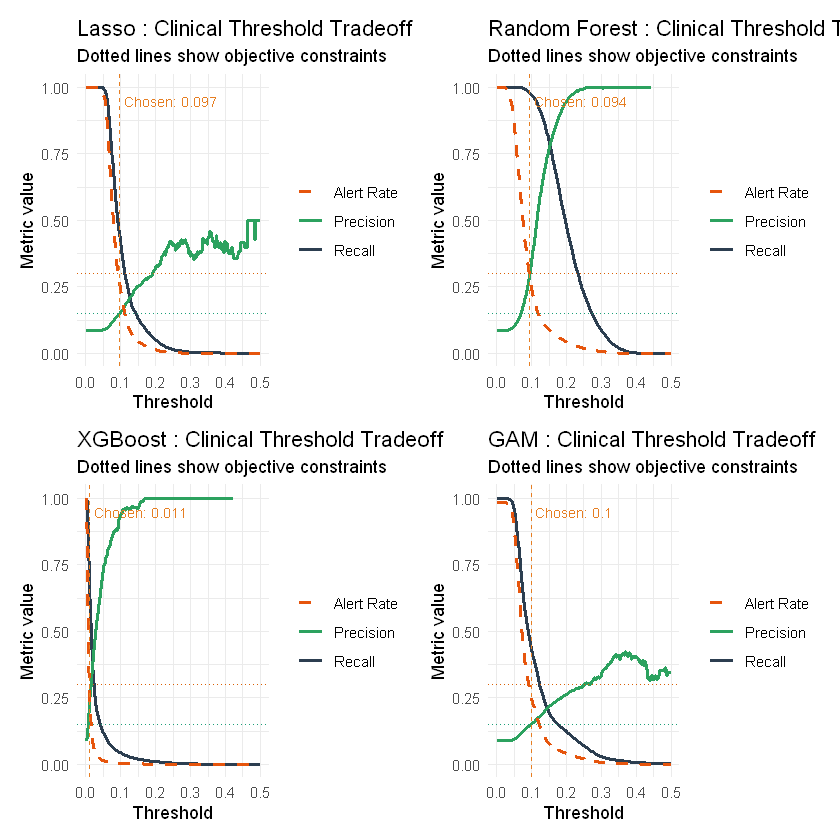

In [36]:
# Clinical objective: care-management outreach under limited capacity.
# Goal: maximize recall while enforcing minimum precision and maximum alert rate.
clinical_objective <- list(
  name = "Care-management outreach for 30-day readmission prevention",
  min_precision = 0.15,
  max_alert_rate = 0.30
)

compute_threshold_curve <- function(pred_df, prob_col, thresholds = seq(0.001, 0.5, by = 0.001)) {
  pos_label <- levels(pred_df$readmitted_binary)[2]
  truth_pos <- pred_df$readmitted_binary == pos_label
  prob_vals <- pred_df[[prob_col]]

  curve <- lapply(thresholds, function(th) {
    pred_pos <- prob_vals >= th

    tp <- sum(pred_pos & truth_pos)
    fp <- sum(pred_pos & !truth_pos)
    fn <- sum(!pred_pos & truth_pos)
    tn <- sum(!pred_pos & !truth_pos)

    precision <- if ((tp + fp) > 0) tp / (tp + fp) else NA_real_
    recall <- if ((tp + fn) > 0) tp / (tp + fn) else NA_real_
    specificity <- if ((tn + fp) > 0) tn / (tn + fp) else NA_real_
    bal_accuracy <- mean(c(recall, specificity), na.rm = TRUE)
    f_meas <- if (!is.na(precision) && !is.na(recall) && (precision + recall) > 0) {
      2 * precision * recall / (precision + recall)
    } else {
      NA_real_
    }
    alert_rate <- mean(pred_pos)

    tibble(
      threshold = th,
      precision = precision,
      recall = recall,
      specificity = specificity,
      bal_accuracy = bal_accuracy,
      f_meas = f_meas,
      alert_rate = alert_rate
    )
  }) %>% dplyr::bind_rows()

  curve
}

select_threshold_by_objective <- function(curve_df, min_precision, max_alert_rate) {
  feasible <- curve_df %>%
    dplyr::filter(!is.na(precision), precision >= min_precision, alert_rate <= max_alert_rate)

  if (nrow(feasible) > 0) {
    feasible %>%
      dplyr::arrange(dplyr::desc(recall), dplyr::desc(precision), dplyr::desc(bal_accuracy), alert_rate) %>%
      dplyr::slice_head(n = 1) %>%
      dplyr::mutate(selection_mode = "meets_constraints")
  } else {
    curve_df %>%
      dplyr::filter(!is.na(precision)) %>%
      dplyr::arrange(dplyr::desc(f_meas), dplyr::desc(recall), alert_rate) %>%
      dplyr::slice_head(n = 1) %>%
      dplyr::mutate(selection_mode = "fallback_best_f1")
  }
}

plot_threshold_tradeoff <- function(curve_df, selected_row, model_label, min_precision, max_alert_rate) {
  ggplot(curve_df, aes(x = threshold)) +
    geom_line(aes(y = recall, color = "Recall"), linewidth = 1) +
    geom_line(aes(y = precision, color = "Precision"), linewidth = 1) +
    geom_line(aes(y = alert_rate, color = "Alert Rate"), linewidth = 1, linetype = "dashed") +
    geom_hline(yintercept = min_precision, color = "#1b9e77", linetype = "dotted") +
    geom_hline(yintercept = max_alert_rate, color = "#d95f02", linetype = "dotted") +
    geom_vline(xintercept = selected_row$threshold, color = "#e67e22", linetype = "dashed") +
    annotate(
      "text",
      x = selected_row$threshold,
      y = 0.95,
      label = paste0("Chosen: ", round(selected_row$threshold, 3)),
      color = "#e67e22",
      hjust = -0.05,
      size = 3
    ) +
    scale_color_manual(values = c("Recall" = "#2c3e50", "Precision" = "#2ca25f", "Alert Rate" = "#e6550d")) +
    coord_cartesian(ylim = c(0, 1)) +
    theme_minimal() +
    labs(
      title = paste(model_label, ": Clinical Threshold Tradeoff"),
      subtitle = "Dotted lines show objective constraints",
      x = "Threshold",
      y = "Metric value",
      color = NULL
    )
}

# Build CV threshold curves
lr_curve <- compute_threshold_curve(lr_preds_cv, prob_col_lr)
rf_curve <- compute_threshold_curve(rf_preds_cv, prob_col_rf)
xgb_curve <- compute_threshold_curve(xgb_preds_cv, prob_col_xgb)
gam_curve <- compute_threshold_curve(gam_preds_cv, prob_col_gam)

# Select thresholds according to the clinical objective
opt_lr_row <- select_threshold_by_objective(lr_curve, clinical_objective$min_precision, clinical_objective$max_alert_rate)
opt_rf_row <- select_threshold_by_objective(rf_curve, clinical_objective$min_precision, clinical_objective$max_alert_rate)
opt_xgb_row <- select_threshold_by_objective(xgb_curve, clinical_objective$min_precision, clinical_objective$max_alert_rate)
opt_gam_row <- select_threshold_by_objective(gam_curve, clinical_objective$min_precision, clinical_objective$max_alert_rate)

# Keep backward-compatible objects for the next cell
opt_lr <- list(threshold = opt_lr_row$threshold, data = opt_lr_row, curve = lr_curve)
opt_rf <- list(threshold = opt_rf_row$threshold, data = opt_rf_row, curve = rf_curve)
opt_xgb <- list(threshold = opt_xgb_row$threshold, data = opt_xgb_row, curve = xgb_curve)
opt_gam <- list(threshold = opt_gam_row$threshold, data = opt_gam_row, curve = gam_curve)

# Summarize selected operating points on CV predictions
clinical_selection <- dplyr::bind_rows(
  dplyr::mutate(opt_lr_row, model = "Lasso"),
  dplyr::mutate(opt_rf_row, model = "Random Forest"),
  dplyr::mutate(opt_xgb_row, model = "XGBoost"),
  dplyr::mutate(opt_gam_row, model = "GAM")
) %>%
  dplyr::select(model, threshold, selection_mode, precision, recall, specificity, bal_accuracy, f_meas, alert_rate)

cat("Clinical objective selected:\n")
cat("  ", clinical_objective$name, "\n", sep = "")
cat("  Min precision:", clinical_objective$min_precision, "\n")
cat("  Max alert rate:", clinical_objective$max_alert_rate, "\n\n")
cat("Selected thresholds from CV predictions:\n")
print(clinical_selection)

# Plot tradeoffs for all models
p_lr_obj <- plot_threshold_tradeoff(lr_curve, opt_lr_row, "Lasso", clinical_objective$min_precision, clinical_objective$max_alert_rate)
p_rf_obj <- plot_threshold_tradeoff(rf_curve, opt_rf_row, "Random Forest", clinical_objective$min_precision, clinical_objective$max_alert_rate)
p_xgb_obj <- plot_threshold_tradeoff(xgb_curve, opt_xgb_row, "XGBoost", clinical_objective$min_precision, clinical_objective$max_alert_rate)
p_gam_obj <- plot_threshold_tradeoff(gam_curve, opt_gam_row, "GAM", clinical_objective$min_precision, clinical_objective$max_alert_rate)

(p_lr_obj | p_rf_obj) / (p_xgb_obj | p_gam_obj)
ggsave("outputs/threshold_clinical_objective_plots.png", width = 12, height = 8, dpi = 300)

In [38]:
apply_tuning <- function(pred_df, prob_col, threshold, model_label) {
  truth_levels <- levels(pred_df$readmitted_binary)
  pos_label <- truth_levels[2]

  tuned_df <- pred_df %>%
    mutate(
      .pred_tuned = ifelse(!!rlang::sym(prob_col) >= threshold,
                           "Yes (<30=1)", "No (<30=0)"),
      .pred_tuned = factor(.pred_tuned, levels = truth_levels)
    )

  cat("\n---", model_label, "Tuned Confusion Matrix (Threshold:", round(threshold, 3), ") ---\n")
  print(conf_mat(tuned_df, truth = readmitted_binary, estimate = .pred_tuned))

  tuned_metrics <- dplyr::bind_rows(
    accuracy(tuned_df, truth = readmitted_binary, estimate = .pred_tuned),
    bal_accuracy(tuned_df, truth = readmitted_binary, estimate = .pred_tuned),
    precision(tuned_df, truth = readmitted_binary, estimate = .pred_tuned, event_level = "second"),
    recall(tuned_df, truth = readmitted_binary, estimate = .pred_tuned, event_level = "second"),
    specificity(tuned_df, truth = readmitted_binary, estimate = .pred_tuned, event_level = "second"),
    f_meas(tuned_df, truth = readmitted_binary, estimate = .pred_tuned, event_level = "second")
  )

  cat("\n", model_label, " tuned metrics (held-out test set):\n", sep = "")
  print(tuned_metrics)

  metric_value <- function(tbl, metric_name) {
    tbl$.estimate[tbl$.metric == metric_name][1]
  }

  tibble(
    model = model_label,
    threshold = threshold,
    accuracy = metric_value(tuned_metrics, "accuracy"),
    bal_accuracy = metric_value(tuned_metrics, "bal_accuracy"),
    precision = metric_value(tuned_metrics, "precision"),
    recall = metric_value(tuned_metrics, "recall"),
    specificity = metric_value(tuned_metrics, "specificity"),
    f_meas = metric_value(tuned_metrics, "f_meas"),
    alert_rate = mean(tuned_df$.pred_tuned == pos_label)
  )
}

cat("Applying clinically selected CV thresholds to held-out test predictions.\n")

# Apply clinically selected thresholds to held-out test predictions only
test_summary <- dplyr::bind_rows(
  apply_tuning(lr_preds_test,  prob_col_lr,  opt_lr$threshold,  "Lasso"),
  apply_tuning(rf_preds_test,  prob_col_rf,  opt_rf$threshold,  "Random Forest"),
  apply_tuning(xgb_preds_test, prob_col_xgb, opt_xgb$threshold, "XGBoost"),
  apply_tuning(gam_preds_test, prob_col_gam, opt_gam$threshold, "GAM")
)

if (exists("clinical_objective")) {
  objective_eval <- test_summary %>%
    mutate(
      meets_precision = precision >= clinical_objective$min_precision,
      meets_alert_rate = alert_rate <= clinical_objective$max_alert_rate,
      meets_objective = meets_precision & meets_alert_rate
    )

  cat("\n--- Objective Check on Held-out Test Set ---\n")
  print(
    objective_eval %>%
      select(model, threshold, precision, recall, specificity, f_meas, bal_accuracy, alert_rate, meets_objective)
  )

  eligible <- objective_eval %>%
    filter(meets_objective) %>%
    arrange(desc(recall), desc(f_meas), desc(bal_accuracy))

  if (nrow(eligible) > 0) {
    recommended <- eligible %>% slice_head(n = 1)
    cat("\nRecommended model under clinical objective:\n")
    print(recommended %>% select(model, threshold, precision, recall, alert_rate, f_meas, bal_accuracy))
  } else {
    cat("\nNo model satisfied the clinical objective on held-out test data.\n")
  }
}

Applying clinically selected CV thresholds to held-out test predictions.

--- Lasso Tuned Confusion Matrix (Threshold: 0.097 ) ---
             Truth
Prediction    No (<30=0) Yes (<30=1)
  No (<30=0)        9872         739
  Yes (<30=1)       3121         569

Lasso tuned metrics (held-out test set):
# A tibble: 6 × 3
  .metric      .estimator .estimate
  <chr>        <chr>          <dbl>
1 accuracy     binary         0.730
2 bal_accuracy binary         0.597
3 precision    binary         0.154
4 recall       binary         0.435
5 specificity  binary         0.760
6 f_meas       binary         0.228

--- Random Forest Tuned Confusion Matrix (Threshold: 0.094 ) ---
             Truth
Prediction    No (<30=0) Yes (<30=1)
  No (<30=0)        8533         600
  Yes (<30=1)       4460         708

Random Forest tuned metrics (held-out test set):
# A tibble: 6 × 3
  .metric      .estimator .estimate
  <chr>        <chr>          <dbl>
1 accuracy     binary         0.646
2 bal_accuracy bina